# Proyecto Curso Intermedio de Analítica Avanzada

En este archivo se encuentran las pruebas realizadas para validar los modelos con sus parámetros optimizados. Este repositorio ha sido elaborado para poder analizar ciertas problemáticas de la NBA con modelos de machine learning y deep learning. Los autores de este proyecto son:

- Luis Alberto Arias Llaguno
- David Ceballos Mata
- Rubén Octavio Flores Ramos

En este archivo se verá problema por problema los resultados obtenidos para validar los modelos con sus parámetros optimizados. Asimismo, se verá la exploración de datos y la limpieza de datos de la api de la NBA para poder obtener los datos necesarios para los modelos.

# 0. Importación de librerías

In [ ]:
# Instalación de librerías

#%pip install nba_api
#%pip install tensorflow
#%pip install keras
#%pip install keras_tuner
%pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.1.2-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 8.5 MB/s eta 0:00:09
   - -------------------------------------- 3.4/72.0 MB 13.4 MB/s eta 0:00:06
   --- ------------------------------------ 6.0/72.

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device



In [2]:
# Importación de librerías

from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams
from nba_api.stats.static import players
from nba_api.stats.endpoints import leaguedashplayerstats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score, r2_score
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

import mlflow
import mlflow.tensorflow

C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

# 1. Exploración de datos

# 2. Problemas a Resolver

## 2.1 Predicción de rendimiento partido a partido usando LSTM (Parte 1) (Luis)

### Problema: 
Predecir la línea de puntos, de un equipo (en este caso Lakers) en su próximo partido tomando en cuenta los juegos anteriores. Para este problema, vamos a probar con los 3, 5, y 10 juegos anteriores para poder predecir los puntos de los futuros juegos de los lakers. En esta parte 1 se puede ver que solo se toman en cuenta los juegos de los Lakers como características para el modelo de redes neuronales.

### 2.1.1 Obtención y de datos

In [4]:
# Obtener el ID de los Lakers
nba_teams = teams.get_teams()
lakers = [team for team in nba_teams if team['full_name'] == 'Los Angeles Lakers'][0]
lakers_id = lakers['id']

# Usar LeagueGameFinder para obtener todos los juegos de los Lakers
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=lakers_id)
games = gamefinder.get_data_frames()[0]

# Crear DataFrame con las columnas más relevantes
df_lakers = games[[
    'SEASON_ID',           # Temporada
    'GAME_ID',             # ID del juego
    'GAME_DATE',           # Fecha del juego
    'MATCHUP',             # Matchup (LAL vs. OPP o LAL @ OPP)
    'WL',                  # Win/Loss
    'MIN',                 # Minutos jugados
    'PTS',                 # Puntos anotados
    'FGM',                 # Field Goals Made (tiros de campo anotados)
    'FGA',                 # Field Goals Attempted (tiros de campo intentados)
    'FG_PCT',              # Porcentaje de tiros de campo
    'FG3M',                # 3-Point Field Goals Made (triples anotados)
    'FG3A',                # 3-Point Field Goals Attempted (triples intentados)
    'FG3_PCT',             # Porcentaje de triples
    'FTM',                 # Free Throws Made (tiros libres anotados)
    'FTA',                 # Free Throws Attempted (tiros libres intentados)
    'FT_PCT',              # Porcentaje de tiros libres
    'OREB',                # Rebotes ofensivos
    'DREB',                # Rebotes defensivos
    'REB',                 # Rebotes totales
    'AST',                 # Asistencias
    'STL',                 # Robos
    'BLK',                 # Bloqueos
    'TOV',                 # Pérdidas de balón
    'PF',                  # Faltas personales
    'PLUS_MINUS'           # Plus/Minus
]].copy()

df_lakers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4101 entries, 0 to 4100
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SEASON_ID   4101 non-null   object 
 1   GAME_ID     4101 non-null   object 
 2   GAME_DATE   4101 non-null   object 
 3   MATCHUP     4101 non-null   object 
 4   WL          4099 non-null   object 
 5   MIN         4101 non-null   int64  
 6   PTS         4101 non-null   int64  
 7   FGM         4101 non-null   int64  
 8   FGA         4101 non-null   int64  
 9   FG_PCT      4101 non-null   float64
 10  FG3M        4101 non-null   int64  
 11  FG3A        4101 non-null   int64  
 12  FG3_PCT     4089 non-null   float64
 13  FTM         4101 non-null   int64  
 14  FTA         4101 non-null   int64  
 15  FT_PCT      4099 non-null   float64
 16  OREB        4101 non-null   int64  
 17  DREB        4101 non-null   int64  
 18  REB         4101 non-null   int64  
 19  AST         4101 non-null  

### 2.1.2 Limpieza de datos

In [5]:
# Convertir la fecha a formato datetime
df_lakers['GAME_DATE'] = pd.to_datetime(df_lakers['GAME_DATE']) 

# Ordenar por fecha (más reciente primero)
df_lakers = df_lakers.sort_values('GAME_DATE', ascending=True).reset_index(drop=True) 

# Agregar columna para identificar si es juego en casa o de visitante
df_lakers['ES_CASA'] = df_lakers['MATCHUP'].str.contains('vs.').astype(int)

# Extraer el oponente
df_lakers['OPONENTE'] = df_lakers['MATCHUP'].str.split().str[-1]

# Eliminar plus_minus
df_lakers = df_lakers.drop(columns=['PLUS_MINUS']) 

# Eliminar filas con ANY valor nulo en df_lakers
df_lakers = df_lakers.dropna().reset_index(drop=True) 

# Crear columna WIN (1 para victoria, 0 para derrota)
df_lakers['WIN'] = (df_lakers['WL'] == 'W').astype(int)

# Contar los días que hubo entre juegos
df_lakers['DAYS_REST'] = df_lakers['GAME_DATE'].diff().dt.days
df_lakers['DAYS_REST'] = df_lakers['DAYS_REST'].fillna(df_lakers['DAYS_REST'].median()) # Rellenar valores nulos con la mediana
df_lakers['DAYS_REST'] = df_lakers['DAYS_REST'].astype(int)

# Visualizar los datos
pd.set_option('display.max_columns', None)
df_lakers.info()
df_lakers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4087 entries, 0 to 4086
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   SEASON_ID  4087 non-null   object        
 1   GAME_ID    4087 non-null   object        
 2   GAME_DATE  4087 non-null   datetime64[ns]
 3   MATCHUP    4087 non-null   object        
 4   WL         4087 non-null   object        
 5   MIN        4087 non-null   int64         
 6   PTS        4087 non-null   int64         
 7   FGM        4087 non-null   int64         
 8   FGA        4087 non-null   int64         
 9   FG_PCT     4087 non-null   float64       
 10  FG3M       4087 non-null   int64         
 11  FG3A       4087 non-null   int64         
 12  FG3_PCT    4087 non-null   float64       
 13  FTM        4087 non-null   int64         
 14  FTA        4087 non-null   int64         
 15  FT_PCT     4087 non-null   float64       
 16  OREB       4087 non-null   int64         


,SEASON_ID,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,ES_CASA,OPONENTE,WIN,DAYS_REST
0,21983,0028300010,1983-10-29,LAL @ UTH,W,240,120,46,98,0.469,0,1,0.000,28,39,0.718,29,31,60,25,10,10,20,41,0,UTH,1,2
1,21983,0028300035,1983-11-02,LAL @ SDC,L,240,106,43,96,0.448,1,2,0.500,19,25,0.760,16,33,49,29,14,7,24,24,0,SDC,0,4
2,21983,0028300053,1983-11-05,LAL @ DAL,L,240,102,47,97,0.485,0,2,0.000,8,12,0.667,18,23,41,29,7,8,20,27,0,DAL,0,3
3,21983,0028300066,1983-11-08,LAL @ DEN,W,240,133,49,106,0.462,2,3,0.667,33,36,0.917,22,31,53,30,11,8,23,31,0,DEN,1,3
4,21983,0028300068,1983-11-09,LAL vs. DAL,W,240,120,50,94,0.532,2,3,0.667,18,28,0.643,16,33,49,33,7,6,17,31,1,DAL,1,1


### 2.1.3 Definición de columnas de features y target y Creación de Datasets de Entrenamiento y Validación

In [7]:
feature_cols = [
    'ES_CASA',
    'WIN',
    'MIN',
    'FGM', 'FGA', 'FG_PCT',
    'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT',
    'OREB', 'DREB', 'REB',
    'AST', 'STL', 'BLK',
    'TOV', 'PF',
    'DAYS_REST'
]

target_col = 'PTS'

data_features = df_lakers[feature_cols].values.astype('float32')
data_target = df_lakers[target_col].values.astype('float32')

print("Features shape (sin secuencias):", data_features.shape)
print("Target shape (sin secuencias):", data_target.shape)

Features shape (sin secuencias): (4087, 21)
Target shape (sin secuencias): (4087,)


In [8]:
# Función para construir secuencias de longitud N
def build_sequences(features, target, seq_len=5):
    X, y = [], []
    n_samples = len(features)
    
    for i in range(n_samples - seq_len):
        seq_x = features[i:i+seq_len]
        seq_y = target[i+seq_len]    # Puntos del partido siguiente
        X.append(seq_x)
        y.append(seq_y)
    
    return np.array(X), np.array(y)

# Función para preparar datos para secuencias de longitud N
def prepare_data_for_seq_len(seq_len):
    X, y = build_sequences(data_features, data_target, seq_len=seq_len)
    print(f"\nSEQ_LEN = {seq_len} -> X: {X.shape}, y: {y.shape}")
    
    # split temporal 70/15/15
    n = X.shape[0]
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_val   = X[train_size:train_size+val_size]
    y_val   = y[train_size:train_size+val_size]
    X_test  = X[train_size+val_size:]
    y_test  = y[train_size+val_size:]
    
    num_features = X.shape[2]
    
    # Escalar
    X_train_2d = X_train.reshape(-1, num_features)
    X_val_2d   = X_val.reshape(-1, num_features)
    X_test_2d  = X_test.reshape(-1, num_features)
    
    scaler = StandardScaler()
    X_train_scaled_2d = scaler.fit_transform(X_train_2d)
    X_val_scaled_2d   = scaler.transform(X_val_2d)
    X_test_scaled_2d  = scaler.transform(X_test_2d)
    
    X_train_scaled = X_train_scaled_2d.reshape(X_train.shape)
    X_val_scaled   = X_val_scaled_2d.reshape(X_val.shape)
    X_test_scaled  = X_test_scaled_2d.reshape(X_test.shape)
    
    return (
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test,
        num_features, scaler
    )

### 2.1.4 Modelo Tuneado con Keras

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

def build_lstm_model(hp, seq_len, num_features):
    model = tf.keras.Sequential()
    
    units = hp.Int('lstm_units', min_value=16, max_value=128, step=16)
    model.add(
        layers.LSTM(
            units,
            return_sequences=False,
            input_shape=(seq_len, num_features)
        )
    )
    
    dropout_rate = hp.Float('dropout_rate', 0.0, 0.5, step=0.1)
    model.add(layers.Dropout(dropout_rate))
    
    dense_units = hp.Int('dense_units', min_value=8, max_value=64, step=8)
    model.add(layers.Dense(dense_units, activation='relu'))
    
    model.add(layers.Dense(1, activation='linear'))
    
    optimizer_name = hp.Choice('optimizer', ['sgd', 'rmsprop', 'adam'])
    learning_rate = hp.Float(
        'learning_rate',
        min_value=1e-4,
        max_value=1e-2,
        sampling='log'
    )
    
    clipnorm = hp.Choice('clipnorm', values=[0.0, 1.0, 2.0])
    clip_value = None if clipnorm == 0.0 else clipnorm
    
    if optimizer_name == 'sgd':
        momentum = hp.Float('momentum', min_value=0.0, max_value=0.9, step=0.3)
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=momentum,
            clipnorm=clip_value
        )
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate,
            clipnorm=clip_value
        )
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=clip_value
        )
    
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )
    
    return model


class BatchSizeTuner(kt.Hyperband):
    """Tuner que también tunea batch_size vía hp."""
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        batch_size = hp.Choice('batch_size', [16, 32, 64])
        kwargs['batch_size'] = batch_size
        return super().run_trial(trial, *args, **kwargs)


### 2.1.5 MLflow con la búsqueda de hiperparámetros óptimos

In [10]:
import os
import shutil
from pathlib import Path
import mlflow
import mlflow.tensorflow

# 1. Carpeta raíz PARA MLflow (fuera del repo)
ml_root = Path(r"C:\Downloads\mlflow_nba")

# 2. Borrar lo que hubiera antes (si quieres empezar limpio)
shutil.rmtree(ml_root, ignore_errors=True)

# 3. Crear la carpeta raíz y la subcarpeta .trash (MUY IMPORTANTE)
ml_root.mkdir(parents=True, exist_ok=True)
trash_dir = ml_root / ".trash"
trash_dir.mkdir(exist_ok=True)

print("MLflow root:", ml_root)
print("Existe root:", ml_root.exists(), " / es dir:", ml_root.is_dir())
print("Existe .trash:", trash_dir.exists(), " / es dir:", trash_dir.is_dir())

# 4. Configurar tracking_uri para que apunte ahí
tracking_uri = ml_root.as_uri()  # file:///C:/Downloads/mlflow_nba
mlflow.set_tracking_uri(tracking_uri)
print("Tracking URI actual:", mlflow.get_tracking_uri())

# 5. Crear/usar experimento y activar autolog
mlflow.set_experiment("nba_lakers_lstm")
mlflow.tensorflow.autolog(disable=True)


C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/12/11 21:14:46 INFO mlflow.tracking.fluent: Experiment with name 'nba_lakers_lstm' does not exist. Creating a new experiment.


MLflow root: C:\Downloads\mlflow_nba
Existe root: True  / es dir: True
Existe .trash: True  / es dir: True
Tracking URI actual: file:///C:/Downloads/mlflow_nba


In [11]:
with mlflow.start_run(run_name="prueba_en_downloads"):
    mlflow.log_param("test_param", 123)
    mlflow.log_metric("test_metric", 0.99)

print("Contenido de C:\\Downloads\\mlflow_nba:", os.listdir(ml_root))
for name in os.listdir(ml_root):
    print("  ", name)


Contenido de C:\Downloads\mlflow_nba: ['.trash', '957380413892287742']
   .trash
   957380413892287742


In [12]:
from pathlib import Path
import shutil

kt_dir = Path(r"E:\001 - Portafolio Anáhuac\01 - Ingeniería en Tecnologías de la Información\4to Semestre\Analítica Avanzada\proyecto-analitica-nba") / "kt_lakers_runs"
shutil.rmtree(kt_dir, ignore_errors=True)
kt_dir.mkdir(parents=True, exist_ok=True)
base_dir = kt_dir.as_posix()

print("Keras Tuner dir:", base_dir)


Keras Tuner dir: E:/001 - Portafolio Anáhuac/01 - Ingeniería en Tecnologías de la Información/4to Semestre/Analítica Avanzada/proyecto-analitica-nba/kt_lakers_runs


In [13]:
import os
import shutil
from pathlib import Path

# Carpeta para Keras Tuner (FUERA del repo)
kt_root = Path(r"C:\Downloads\kt_lakers_lstm")

# Borramos cualquier cosa vieja
shutil.rmtree(kt_root, ignore_errors=True)

# Creamos carpeta limpia
kt_root.mkdir(parents=True, exist_ok=True)

# Usamos ruta tipo POSIX (con /) que TF maneja bien
base_dir = kt_root.as_posix()

print("Keras Tuner base_dir:", base_dir)
print("Existe:", os.path.exists(base_dir), " / es dir:", os.path.isdir(base_dir))
print("Contenido:", os.listdir(base_dir))


Keras Tuner base_dir: C:/Downloads/kt_lakers_lstm
Existe: True  / es dir: True
Contenido: []


In [12]:
seq_len_candidates = [3, 5, 10]   # SEQ_LEN (los juegos anteriores que se requieren como contexto para predecir el siguiente)
max_epochs = 40

results = []

for seq_len in seq_len_candidates:
    (
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test,
        num_features, scaler
    ) = prepare_data_for_seq_len(seq_len)

    with mlflow.start_run(run_name=f"tuning_seq{seq_len}"):

        mlflow.log_param("seq_len", seq_len)

        def hypermodel(hp):
            return build_lstm_model(hp, seq_len, num_features)

        tuner = BatchSizeTuner(
            hypermodel,
            objective='val_loss',
            max_epochs=max_epochs,
            factor=3,
            directory=base_dir,
            project_name=f"seq_{seq_len}",
            overwrite=True
        )

        stop_early = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        tuner.search(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[stop_early],
            verbose=1
        )

        # Mejor conjunto de hiperparámetros
        best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
        best_val_loss = best_trial.score

        # Construir modelo ganador
        best_model = tuner.hypermodel.build(best_hp)

        history = best_model.fit(
            np.concatenate([X_train_scaled, X_val_scaled], axis=0),
            np.concatenate([y_train, y_val], axis=0),
            epochs=max_epochs,
            batch_size=best_hp.get('batch_size'),
            callbacks=[stop_early],
            verbose=0
        )

        test_loss, test_mae = best_model.evaluate(X_test_scaled, y_test, verbose=0)

        # Logear solo hiperparámetros ganadores y métricas finales
        mlflow.log_metric("best_val_loss", float(best_val_loss))
        mlflow.log_metric("test_mse", float(test_loss))
        mlflow.log_metric("test_mae", float(test_mae))

        for name, value in best_hp.values.items():
            # para evitar conflictos con nombres reservados, prefijamos
            mlflow.log_param(f"best_{name}", value)

        # Guardar en lista para imprimir resumen al final
        run_result = {
            "seq_len": seq_len,
            "best_val_loss": float(best_val_loss),
            "test_mse": float(test_loss),
            "test_mae": float(test_mae),
        }
        for name, value in best_hp.values.items():
            run_result[name] = value

        results.append(run_result)

Trial 90 Complete [00h 00m 14s]
val_loss: 184.5052490234375

Best val_loss So Far: 158.71412658691406
Total elapsed time: 00h 09m 33s


C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


### 2.1.6 Métricas e Interpretación

In [13]:
def print_results_for_seq_len(results, seq_len):
    print("\n" + "="*80)
    print(f"======================= RESULTADOS COMPLETOS: SEQ_LEN = {seq_len} =======================")
    print("="*80)

    filtered = [r for r in results if r["seq_len"] == seq_len]
    if not filtered:
        print(f"No hay resultados para SEQ_LEN={seq_len}.")
        return

    r = filtered[0]

    # Métricas
    print(f"\nbest_val_loss : {r['best_val_loss']}")
    print(f"test_mse       : {r['test_mse']}")
    print(f"test_mae       : {r['test_mae']}")

    print("\nHiperparámetros ganadores:")
    for k, v in r.items():
        if k not in ["seq_len", "best_val_loss", "test_mse", "test_mae"]:
            print(f"  - {k}: {v}")

    print("="*80 + "\n")


# Imprimir resultados completos para cada SEQ_LEN
print_results_for_seq_len(results, 3)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 3 =======================

best_val_loss : 165.90769958496094
test_mse       : 205.82420349121094
test_mae       : 11.53972053527832

Hiperparámetros ganadores:
  - lstm_units: 16
  - dropout_rate: 0.4
  - dense_units: 8
  - optimizer: sgd
  - learning_rate: 0.0038011372648135925
  - clipnorm: 1.0
  - momentum: 0.8999999999999999
  - batch_size: 32
  - tuner/epochs: 40
  - tuner/initial_epoch: 0
  - tuner/bracket: 0
  - tuner/round: 0



In [14]:
print_results_for_seq_len(results, 5)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 5 =======================

best_val_loss : 161.1466827392578
test_mse       : 230.9376220703125
test_mae       : 12.219761848449707

Hiperparámetros ganadores:
  - lstm_units: 128
  - dropout_rate: 0.30000000000000004
  - dense_units: 16
  - optimizer: sgd
  - learning_rate: 0.0017311246306854196
  - clipnorm: 0.0
  - momentum: 0.0
  - batch_size: 64
  - tuner/epochs: 40
  - tuner/initial_epoch: 14
  - tuner/bracket: 2
  - tuner/round: 2
  - tuner/trial_id: 0064



In [15]:
print_results_for_seq_len(results, 10)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 10 =======================

best_val_loss : 158.71412658691406
test_mse       : 307.41864013671875
test_mae       : 13.860396385192871

Hiperparámetros ganadores:
  - lstm_units: 48
  - dropout_rate: 0.0
  - dense_units: 24
  - optimizer: adam
  - learning_rate: 0.00306562330900601
  - clipnorm: 1.0
  - momentum: 0.6
  - batch_size: 32
  - tuner/epochs: 40
  - tuner/initial_epoch: 14
  - tuner/bracket: 3
  - tuner/round: 3
  - tuner/trial_id: 0048



En este caso podemos ver que el modelo que usa los 10 juegos anteriores para predecir el siguiente juego es el que tiene mejores métricas. Esto debido a la métrica de MAE (Mean Absolute Error), la cual con su valor de 11.3334 nos dice que el modelo promedio de error es de 11.3334 puntos. En otras palabras, esto dice que el modelo está prediciendo con un error promedio de 11.3334 puntos, osea que de su predicción está en promedio 11.3334 puntos de distancia de la realidad.

In [16]:
# R^2 score

y_pred = best_model.predict(X_test_scaled).flatten()   # predicciones
r2 = r2_score(y_test, y_pred)

print("Coeficiente de determinación R²:", r2)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Coeficiente de determinación R²: -0.5687004327774048


In [17]:
df_lakers['PTS'].mean()

105.26620993393688

Aquí hay que hacer un detenimiento especial en la evaluación de la métrica de R², porque al ser negativo teóricamente significa que el modelo mejora que si es que simplemente sacara el promedio de los valores de la variable objetivo para los juegos anteriores y predijeramos con eso. Esto se debe a un par de factores, principalmente que el promedio de puntos de todos los juegos (que hay en nba_api) de los Lakers es de 105.26, por lo que los juegos de los lakers son bastante estables. Otro factor que tomar en cuenta es que no hay características de los contrincantes, por lo que el modelo no tiene información sobre quién es el contrincante en el juego actual y esto también llega a afectar la precisión de la predicción.

## 2.2 Predicción de rendimiento partido a partido usando LSTM (Parte 2) (Luis)

### Problema: 
Predecir la línea de puntos, de un equipo (en este caso Lakers) en su próximo partido tomando en cuenta los juegos anteriores. Para este problema, vamos a probar con los 3, 5, y 10 juegos anteriores para poder predecir los puntos de los futuros juegos de los lakers. En esta parte 2 se puede ver que no solo se toman en cuenta las características de los Lakers en ese juego, sino que también se toman en cuenta las características de los contrincantes en el mismo juego como características para el modelo de redes neuronales. En teoría, estas nuevas características beneficiarían al modelo debido a que tener las características del contrincante en ese partido también da más contexto sobre el juego y de los contrincantes como han sido en el pasado para poder predecir con mayor exactitud el rendimiento de los Lakers en el próximo partido.

### 2.2.1 Crear dataframe con stats de los contrincantes y Lakers

In [15]:
teams_df = pd.DataFrame(nba_teams)
abbr_to_id = dict(zip(teams_df["abbreviation"], teams_df["id"]))

opp_abbrevs = df_lakers["OPONENTE"].unique()
print("Oponentes únicos:", opp_abbrevs)

# ¿Qué abreviaturas NO están en los equipos oficiales?
missing = [abbr for abbr in opp_abbrevs if abbr not in abbr_to_id]
print("Abreviaturas que no están en nba_teams:", missing)


Oponentes únicos: ['UTH' 'SDC' 'DAL' 'DEN' 'PHX' 'MIL' 'CLE' 'POR' 'SEA' 'CHI' 'GOS' 'NYK'
 'SAN' 'HOU' 'KCK' 'IND' 'BOS' 'WAS' 'ATL' 'PHL' 'NJN' 'DET' 'LAC' 'SAC'
 'MIA' 'CHH' 'ORL' 'MIN' 'VAN' 'TOR' 'SAS' 'GSW' 'UTA' 'PHI' 'MEM' 'NOH'
 'CHA' 'NOK' 'BAR' 'OKC' 'BKN' 'NOP' 'MAC' 'SKT']
Abreviaturas que no están en nba_teams: ['UTH', 'SDC', 'SEA', 'GOS', 'SAN', 'KCK', 'PHL', 'NJN', 'CHH', 'VAN', 'NOH', 'NOK', 'BAR', 'MAC', 'SKT']


In [16]:
# Mapa manual de abreviaturas raras a abreviaturas oficiales de nba_api
abbr_fix_map = {
    "UTH": "UTA",  # Utah Jazz
    "SDC": "LAC",  # San Diego Clippers -> LA Clippers
    "SEA": "OKC",  # Seattle SuperSonics -> Oklahoma City Thunder
    "GOS": "GSW",  # Golden State (a veces codificado raro) -> Golden State Warriors
    "SAN": "SAS",  # San Antonio -> San Antonio Spurs
    "KCK": "SAC",  # Kansas City Kings -> Sacramento Kings
    "PHL": "PHI",  # Philadelphia (viejo código) -> Philadelphia 76ers
    "NJN": "BKN",  # New Jersey Nets -> Brooklyn Nets
    "CHH": "CHA",  # Charlotte Hornets (viejos) -> Charlotte Hornets actuales
    "VAN": "MEM",  # Vancouver Grizzlies -> Memphis Grizzlies
    "NOH": "NOP",  # New Orleans Hornets -> New Orleans Pelicans
    "NOK": "NOP",  # New Orleans/Oklahoma City Hornets -> Pelicans
}

teams_df = pd.DataFrame(nba_teams)
abbr_to_id = dict(zip(teams_df["abbreviation"], teams_df["id"]))

# Aplicar corrección directamente al dataframe de Lakers
df_lakers["OPONENTE"] = df_lakers["OPONENTE"].replace(abbr_fix_map)

# Volver a calcular oponentes únicos
opp_abbrevs = df_lakers["OPONENTE"].unique()
print("Oponentes únicos normalizados:", opp_abbrevs)

# Verificar si ya todos existen
missing = [abbr for abbr in opp_abbrevs if abbr not in abbr_to_id]
print("Abreviaturas fuera de catálogo después de normalizar:", missing)

if missing:
    print("Eliminando partidos contra equipos no-NBA:", missing)
    df_lakers = df_lakers[~df_lakers["OPONENTE"].isin(missing)].reset_index(drop=True)


Oponentes únicos normalizados: ['UTA' 'LAC' 'DAL' 'DEN' 'PHX' 'MIL' 'CLE' 'POR' 'OKC' 'CHI' 'GSW' 'NYK'
 'SAS' 'HOU' 'SAC' 'IND' 'BOS' 'WAS' 'ATL' 'PHI' 'BKN' 'DET' 'MIA' 'CHA'
 'ORL' 'MIN' 'MEM' 'TOR' 'NOP' 'BAR' 'MAC' 'SKT']
Abreviaturas fuera de catálogo después de normalizar: ['BAR', 'MAC', 'SKT']
Eliminando partidos contra equipos no-NBA: ['BAR', 'MAC', 'SKT']


In [17]:
# Esta vez pedimos TODOS los juegos donde el oponente fue LAL
opp_gamefinder = leaguegamefinder.LeagueGameFinder(
    vs_team_id_nullable=lakers_id   # <-- clave: vs_team_id, no team_id
)
df_opp_raw = opp_gamefinder.get_data_frames()[0]
print("df_opp_raw (todos los rivales vs LAL) shape:", df_opp_raw.shape)

# Nos quedamos solo con los GAME_ID que están en df_lakers (por si acaso)
df_opp_raw = df_opp_raw[df_opp_raw["GAME_ID"].isin(df_lakers["GAME_ID"])]
print("df_opp_raw filtrado shape:", df_opp_raw.shape)

# Columnas relevantes del rival (mismas métricas que Lakers)
opp_cols = [
    "GAME_ID",
    "WL",          # Win/Loss del rival
    "MIN",
    "PTS",
    "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT",
    "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB",
    "AST", "STL", "BLK",
    "TOV", "PF",
]

df_opp = df_opp_raw[opp_cols].copy()

# Crear columna OPP_WIN (1 si el rival ganó, 0 si perdió)
df_opp["OPP_WIN"] = (df_opp["WL"] == "W").astype(int)
df_opp = df_opp.drop(columns=["WL"])

# Renombrar métricas del rival con prefijo OPP_
rename_map = {
    col: f"OPP_{col}" for col in df_opp.columns if col != "GAME_ID"
}
df_opp.rename(columns=rename_map, inplace=True)

print("df_opp shape (una fila por equipo-rival en cada juego):", df_opp.shape)
df_opp.head()


df_opp_raw (todos los rivales vs LAL) shape: (4099, 28)
df_opp_raw filtrado shape: (4083, 28)
df_opp shape (una fila por equipo-rival en cada juego): (4083, 21)


,GAME_ID,OPP_MIN,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,OPP_PF,OPP_OPP_WIN
0,0022501204,240,132,43,86,0.500,17,38,0.447,29,36,0.806,9,41,50,25,9,3,10,19,1
1,0022500362,240,108,36,102,0.353,13,36,0.361,23,26,0.885,17,37,54,21,5,4,6,17,0
2,0022500338,239,126,46,84,0.548,24,45,0.533,10,12,0.833,8,30,38,31,9,5,14,20,1
3,0022500336,240,120,44,89,0.494,15,37,0.405,17,21,0.810,14,27,41,39,9,8,15,20,0
4,0022500317,240,125,52,92,0.565,17,39,0.436,4,8,0.500,4,29,33,35,16,1,11,16,1


In [18]:
df_opp.info()
df_opp.head()


<class 'pandas.core.frame.DataFrame'>
Index: 4083 entries, 0 to 4097
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GAME_ID      4083 non-null   object 
 1   OPP_MIN      4083 non-null   int64  
 2   OPP_PTS      4083 non-null   int64  
 3   OPP_FGM      4083 non-null   int64  
 4   OPP_FGA      4083 non-null   int64  
 5   OPP_FG_PCT   4083 non-null   float64
 6   OPP_FG3M     4083 non-null   int64  
 7   OPP_FG3A     4083 non-null   int64  
 8   OPP_FG3_PCT  4044 non-null   float64
 9   OPP_FTM      4083 non-null   int64  
 10  OPP_FTA      4083 non-null   int64  
 11  OPP_FT_PCT   4083 non-null   float64
 12  OPP_OREB     4083 non-null   int64  
 13  OPP_DREB     4083 non-null   int64  
 14  OPP_REB      4083 non-null   int64  
 15  OPP_AST      4083 non-null   int64  
 16  OPP_STL      4083 non-null   int64  
 17  OPP_BLK      4083 non-null   int64  
 18  OPP_TOV      4083 non-null   int64  
 19  OPP_PF     

,GAME_ID,OPP_MIN,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,OPP_PF,OPP_OPP_WIN
0,0022501204,240,132,43,86,0.500,17,38,0.447,29,36,0.806,9,41,50,25,9,3,10,19,1
1,0022500362,240,108,36,102,0.353,13,36,0.361,23,26,0.885,17,37,54,21,5,4,6,17,0
2,0022500338,239,126,46,84,0.548,24,45,0.533,10,12,0.833,8,30,38,31,9,5,14,20,1
3,0022500336,240,120,44,89,0.494,15,37,0.405,17,21,0.810,14,27,41,39,9,8,15,20,0
4,0022500317,240,125,52,92,0.565,17,39,0.436,4,8,0.500,4,29,33,35,16,1,11,16,1


In [19]:
# Dataframe combinado Lakers + Rival

df_lakers_opp = df_lakers.merge(
    df_opp,
    on="GAME_ID",
    how="left",
    validate="one_to_one"  # Si truena aquí es porque hay duplicados, se puede quitar el validate
)

print("df_lakers_opp shape:", df_lakers_opp.shape)
df_lakers_opp.head()

df_lakers_opp shape: (4083, 48)


,SEASON_ID,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,ES_CASA,OPONENTE,WIN,DAYS_REST,OPP_MIN,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,OPP_PF,OPP_OPP_WIN
0,21983,0028300010,1983-10-29,LAL @ UTH,W,240,120,46,98,0.469,0,1,0.000,28,39,0.718,29,31,60,25,10,10,20,41,0,UTA,1,2,240,115,35,77,0.455,1,3,0.333,44,60,0.733,15,26,41,21,8,10,17,27,0
1,21983,0028300035,1983-11-02,LAL @ SDC,L,240,106,43,96,0.448,1,2,0.500,19,25,0.760,16,33,49,29,14,7,24,24,0,LAC,0,4,240,110,47,91,0.516,0,1,0.000,16,23,0.696,11,31,42,30,12,8,20,24,1
2,21983,0028300053,1983-11-05,LAL @ DAL,L,240,102,47,97,0.485,0,2,0.000,8,12,0.667,18,23,41,29,7,8,20,27,0,DAL,0,3,240,107,43,97,0.443,0,2,0.000,21,26,0.808,22,26,48,26,9,4,16,20,1
3,21983,0028300066,1983-11-08,LAL @ DEN,W,240,133,49,106,0.462,2,3,0.667,33,36,0.917,22,31,53,30,11,8,23,31,0,DEN,1,3,240,124,44,96,0.458,0,8,0.000,36,42,0.857,14,30,44,28,15,4,24,26,0
4,21983,0028300068,1983-11-09,LAL vs. DAL,W,240,120,50,94,0.532,2,3,0.667,18,28,0.643,16,33,49,33,7,6,17,31,1,DAL,1,1,240,106,34,83,0.410,0,2,0.000,38,46,0.826,13,30,43,22,7,2,18,23,0


### 2.2.2 Definir columnas de features y target y Creación de Datasets de Entrenamiento y Validación

In [20]:
feature_cols_22 = [
    # Features de los Lakers (igual que en 2.1)
    'ES_CASA',
    'WIN',
    'MIN',
    'FGM', 'FGA', 'FG_PCT',
    'FG3M', 'FG3A', 'FG3_PCT',
    'FTM', 'FTA', 'FT_PCT',
    'OREB', 'DREB', 'REB',
    'AST', 'STL', 'BLK',
    'TOV', 'PF',
    'DAYS_REST',
    
    # Features del rival (prefijo OPP_)
    'OPP_MIN',
    'OPP_PTS',
    'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT',
    'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT',
    'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT',
    'OPP_OREB', 'OPP_DREB', 'OPP_REB',
    'OPP_AST', 'OPP_STL', 'OPP_BLK',
    'OPP_TOV', 'OPP_PF'
]

target_col_22 = 'PTS' 

data_features_22 = df_lakers_opp[feature_cols_22].values.astype('float32')
data_target_22 = df_lakers_opp[target_col_22].values.astype('float32')

print("Features 2.2 shape (sin secuencias):", data_features_22.shape)
print("Target 2.2 shape (sin secuencias):", data_target_22.shape)


Features 2.2 shape (sin secuencias): (4083, 40)
Target 2.2 shape (sin secuencias): (4083,)


### 2.2.3 Preparación de datos secuenciales para el nuevo modelo

In [21]:
def prepare_data_for_seq_len_22(seq_len):
    X, y = build_sequences(data_features_22, data_target_22, seq_len=seq_len)
    print(f"\n[2.2] SEQ_LEN = {seq_len} -> X: {X.shape}, y: {y.shape}")
    
    n = X.shape[0]
    train_size = int(n * 0.7)
    val_size   = int(n * 0.15)
    
    X_train = X[:train_size]
    y_train = y[:train_size]
    X_val   = X[train_size:train_size+val_size]
    y_val   = y[train_size:train_size+val_size]
    X_test  = X[train_size+val_size:]
    y_test  = y[train_size+val_size:]
    
    num_features = X.shape[2]
    
    # Escalado (igual que en 2.1)
    X_train_2d = X_train.reshape(-1, num_features)
    X_val_2d   = X_val.reshape(-1, num_features)
    X_test_2d  = X_test.reshape(-1, num_features)
    
    scaler = StandardScaler()
    X_train_scaled_2d = scaler.fit_transform(X_train_2d)
    X_val_scaled_2d   = scaler.transform(X_val_2d)
    X_test_scaled_2d  = scaler.transform(X_test_2d)
    
    X_train_scaled = X_train_scaled_2d.reshape(X_train.shape)
    X_val_scaled   = X_val_scaled_2d.reshape(X_val.shape)
    X_test_scaled  = X_test_scaled_2d.reshape(X_test.shape)
    
    return (
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test,
        num_features, scaler
    )


### 2.2.4 Flujo de Keras Tuner y MLflow

In [26]:
mlflow.set_experiment("nba_lakers_lstm_con_rival")  # nuevo experimento para Parte 2.2

seq_len_candidates_22 = [3, 5, 10]
max_epochs_22 = 40

results_22 = []

for seq_len in seq_len_candidates_22:
    (
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        X_test_scaled, y_test,
        num_features, scaler
    ) = prepare_data_for_seq_len_22(seq_len)

    with mlflow.start_run(run_name=f"tuning_seq{seq_len}_rival"):

        mlflow.log_param("seq_len", seq_len)

        def hypermodel(hp):
            return build_lstm_model(hp, seq_len, num_features)

        tuner = BatchSizeTuner(
            hypermodel,
            objective='val_loss',
            max_epochs=max_epochs_22,
            factor=3,
            directory=base_dir,
            project_name=f"seq_{seq_len}_rival",
            overwrite=True
        )

        stop_early = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        tuner.search(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            callbacks=[stop_early],
            verbose=1
        )

        # Mejor conjunto de hiperparámetros
        best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
        best_val_loss = best_trial.score

        # Construir modelo ganador y reentrenar con train+val
        best_model = tuner.hypermodel.build(best_hp)

        history = best_model.fit(
            np.concatenate([X_train_scaled, X_val_scaled], axis=0),
            np.concatenate([y_train, y_val], axis=0),
            epochs=max_epochs_22,
            batch_size=best_hp.get('batch_size'),
            callbacks=[stop_early],
            verbose=0
        )

        test_loss, test_mae = best_model.evaluate(X_test_scaled, y_test, verbose=0)

        # Log en MLflow
        mlflow.log_metric("best_val_loss", float(best_val_loss))
        mlflow.log_metric("test_mse", float(test_loss))
        mlflow.log_metric("test_mae", float(test_mae))

        for name, value in best_hp.values.items():
            mlflow.log_param(f"best_{name}", value)

        run_result = {
            "seq_len": seq_len,
            "best_val_loss": float(best_val_loss),
            "test_mse": float(test_loss),
            "test_mae": float(test_mae),
        }
        for name, value in best_hp.values.items():
            run_result[name] = value

        results_22.append(run_result)

Trial 90 Complete [00h 00m 18s]
val_loss: 8832.857421875

Best val_loss So Far: 187.379638671875
Total elapsed time: 00h 15m 02s


C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


### 2.2.5 Métricas y Evaluación

In [27]:
print_results_for_seq_len(results_22, 3)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 3 =======================

best_val_loss : 187.28448486328125
test_mse       : 252.99362182617188
test_mae       : 12.887859344482422

Hiperparámetros ganadores:
  - lstm_units: 112
  - dropout_rate: 0.30000000000000004
  - dense_units: 16
  - optimizer: sgd
  - learning_rate: 0.0003383182105335443
  - clipnorm: 0.0
  - momentum: 0.6
  - batch_size: 32
  - tuner/epochs: 40
  - tuner/initial_epoch: 0
  - tuner/bracket: 0
  - tuner/round: 0



In [28]:
print_results_for_seq_len(results_22, 5)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 5 =======================

best_val_loss : 187.4408721923828
test_mse       : 252.73110961914062
test_mae       : 12.881135940551758

Hiperparámetros ganadores:
  - lstm_units: 32
  - dropout_rate: 0.2
  - dense_units: 8
  - optimizer: sgd
  - learning_rate: 0.0012306883948819032
  - clipnorm: 0.0
  - momentum: 0.8999999999999999
  - batch_size: 64
  - tuner/epochs: 5
  - tuner/initial_epoch: 2
  - tuner/bracket: 3
  - tuner/round: 1
  - tuner/trial_id: 0017



In [29]:
print_results_for_seq_len(results_22, 10)


======================= RESULTADOS COMPLETOS: SEQ_LEN = 10 =======================

best_val_loss : 187.379638671875
test_mse       : 253.57949829101562
test_mae       : 12.90460205078125

Hiperparámetros ganadores:
  - lstm_units: 16
  - dropout_rate: 0.4
  - dense_units: 64
  - optimizer: sgd
  - learning_rate: 0.0005986605913831514
  - clipnorm: 0.0
  - momentum: 0.3
  - batch_size: 32
  - tuner/epochs: 40
  - tuner/initial_epoch: 14
  - tuner/bracket: 2
  - tuner/round: 2
  - tuner/trial_id: 0067



In [30]:
y_pred_22 = best_model.predict(X_test_scaled).flatten()
r2_22 = r2_score(y_test, y_pred_22)
print("R² (modelo con stats del rival):", r2_22)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
R² (modelo con stats del rival): -0.3034573793411255


In [31]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Entrenamiento
y_train_pred = best_model.predict(X_train_scaled).flatten()
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)

# Validación+test (según quieras, aquí test)
y_test_pred = best_model.predict(X_test_scaled).flatten()
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2  = r2_score(y_test, y_test_pred)

print("MAE train :", train_mae)
print("MSE train :", train_mse)
print("MAE test  :", test_mae)
print("MSE test  :", test_mse)
print("R² test   :", test_r2)



90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE train : 10.787086486816406
MSE train : 185.3451385498047
MAE test  : 12.904601097106934
MSE test  : 253.57949829101562
R² test   : -0.3034573793411255


In [33]:
y_mean = np.mean(y_test)
baseline_pred = np.full_like(y_test, y_mean)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2  = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline MSE:", baseline_mse)
print("Baseline R² :", baseline_r2)


Baseline MAE: 10.986564636230469
Baseline MSE: 194.54376220703125
Baseline R² : 0.0


## 2.3 Red Neuronal Densa (ChatGPT)

In [22]:
# Partimos de df_lakers_opp ya construido
df = df_lakers_opp.copy()

# Aseguramos orden temporal
df = df.sort_values("GAME_DATE").reset_index(drop=True)

# -----------------------------
# Rolling averages (últimos 5)
# -----------------------------
window = 5

lakers_base_cols = ["PTS", "FG_PCT", "FG3_PCT", "REB", "AST"]
opp_base_cols    = ["OPP_PTS", "OPP_FG_PCT", "OPP_FG3_PCT", "OPP_REB", "OPP_AST"]

for col in lakers_base_cols:
    df[f"LAL_{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )

for col in opp_base_cols:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )

# -----------------------------
# Rachas de victorias (streaks)
# -----------------------------
def compute_streak(series_win):
    streaks = []
    streak = 0
    for w in series_win:
        if w == 1:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    # shift(1) para que la racha sea "antes del partido actual"
    return pd.Series(streaks).shift(1)

# Asegúrate de que WIN y OPP_WIN son 0/1
df["LAL_WIN_STREAK"] = compute_streak(df["WIN"])
df["OPP_WIN_STREAK"] = compute_streak(df["OPP_OPP_WIN"])

# -----------------------------
# Back-to-back (descanso 0 días)
# -----------------------------
df["LAL_B2B"] = (df["DAYS_REST"] == 0).astype(int)

# -----------------------------
# Definir columnas de features y target
# -----------------------------
feature_cols_b = [
    # contexto básico
    "ES_CASA",
    "DAYS_REST",
    "LAL_B2B",
    
    # forma reciente Lakers
    f"LAL_PTS_roll{window}",
    f"LAL_FG_PCT_roll{window}",
    f"LAL_FG3_PCT_roll{window}",
    f"LAL_REB_roll{window}",
    f"LAL_AST_roll{window}",
    "LAL_WIN_STREAK",
    
    # forma reciente rival
    f"OPP_PTS_roll{window}",
    f"OPP_FG_PCT_roll{window}",
    f"OPP_FG3_PCT_roll{window}",
    f"OPP_REB_roll{window}",
    f"OPP_AST_roll{window}",
    "OPP_WIN_STREAK",
]

target_col_b = "PTS"  # puntos de Lakers en ese partido

# -----------------------------
# Aquí se crea df_model (la parte que te faltaba)
# -----------------------------
df_model = df.dropna(subset=feature_cols_b + [target_col_b]).reset_index(drop=True)

print("Shape df_model:", df_model.shape)
print("Primeras columnas de df_model:", df_model.columns.tolist())


Shape df_model: (3917, 61)
Primeras columnas de df_model: ['SEASON_ID', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'ES_CASA', 'OPONENTE', 'WIN', 'DAYS_REST', 'OPP_MIN', 'OPP_PTS', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_STL', 'OPP_BLK', 'OPP_TOV', 'OPP_PF', 'OPP_OPP_WIN', 'LAL_PTS_roll5', 'LAL_FG_PCT_roll5', 'LAL_FG3_PCT_roll5', 'LAL_REB_roll5', 'LAL_AST_roll5', 'OPP_PTS_roll5', 'OPP_FG_PCT_roll5', 'OPP_FG3_PCT_roll5', 'OPP_REB_roll5', 'OPP_AST_roll5', 'LAL_WIN_STREAK', 'OPP_WIN_STREAK', 'LAL_B2B']


In [23]:
# Ya está ordenado por fecha
n = len(df_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

X_train = train_df[feature_cols_b].values.astype("float32")
y_train = train_df[target_col_b].values.astype("float32")

X_val   = val_df[feature_cols_b].values.astype("float32")
y_val   = val_df[target_col_b].values.astype("float32")

X_test  = test_df[feature_cols_b].values.astype("float32")
y_test  = test_df[target_col_b].values.astype("float32")

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (2741, 15) Val: (588, 15) Test: (588, 15)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler_b = StandardScaler()
X_train_scaled = scaler_b.fit_transform(X_train)
X_val_scaled   = scaler_b.transform(X_val)
X_test_scaled  = scaler_b.transform(X_test)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

def build_mlp_model(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1)  # regresión
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

input_dim = X_train_scaled.shape[1]
mlp_model = build_mlp_model(input_dim)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10341.7686 - mae: 100.7562 - val_loss: 9177.7900 - val_mae: 94.6737
Epoch 2/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6704.9478 - mae: 79.3951 - val_loss: 3699.0007 - val_mae: 57.0794
Epoch 3/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2054.7847 - mae: 38.8701 - val_loss: 1162.8026 - val_mae: 27.8914
Epoch 4/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1285.9528 - mae: 29.0339 - val_loss: 753.0197 - val_mae: 22.1753
Epoch 5/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1040.7960 - mae: 25.9679 - val_loss: 585.0426 - val_mae: 19.3075
Epoch 6/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 912.5944 - mae: 23.9244 - val_loss: 483.3103 - val_mae: 17.3965
Epoch 7/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 859.2308 - mae: 23.5695 - val_loss: 426.0462 - val_mae: 16.2470
Epoch 8/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 794.1824 - mae: 22.6634 - val_loss: 381.6243 - val_mae: 15.3283
Epoch 

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluación directa de Keras
test_loss, test_mae = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print("MLP - test MSE (Keras):", test_loss)
print("MLP - test MAE (Keras):", test_mae)

# Métricas más completas
y_pred = mlp_model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nMLP - MAE:", mae)
print("MLP - MSE:", mse)
print("MLP - R² :", r2)

# Baseline media para comparar
y_mean = np.mean(y_test)
baseline_pred = np.full_like(y_test, y_mean)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2  = r2_score(y_test, baseline_pred)

print("\nBaseline MAE:", baseline_mae)
print("Baseline MSE:", baseline_mse)
print("Baseline R² :", baseline_r2)


MLP - test MSE (Keras): 191.20912170410156
MLP - test MAE (Keras): 10.979021072387695
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

MLP - MAE: 10.979021072387695
MLP - MSE: 191.20912170410156
MLP - R² : 0.0252760648727417

Baseline MAE: 11.024249076843262
Baseline MSE: 196.16746520996094
Baseline R² : 0.0


In [27]:
import mlflow
import mlflow.keras  # o mlflow.tensorflow según tu versión

mlflow.set_experiment("nba_lakers_mlp_tabular")

with mlflow.start_run(run_name="mlp_tabular_roll5"):
    mlflow.log_param("model_type", "MLP_tabular")
    mlflow.log_param("window", window)
    mlflow.log_param("hidden_layers", [64, 32])
    mlflow.log_param("dropout", 0.3)
    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_metric("test_mae", float(mae))
    mlflow.log_metric("test_mse", float(mse))
    mlflow.log_metric("test_r2", float(r2))
    
    # Guardar el modelo
    mlflow.keras.log_model(mlp_model, artifact_path="mlp_model")


2025/12/11 21:16:03 INFO mlflow.tracking.fluent: Experiment with name 'nba_lakers_mlp_tabular' does not exist. Creating a new experiment.
2025/12/11 21:16:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/11 21:16:03 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/12/11 21:16:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [28]:
df_lakers_opp.head()

,SEASON_ID,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,ES_CASA,OPONENTE,WIN,DAYS_REST,OPP_MIN,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,OPP_PF,OPP_OPP_WIN
0,21983,0028300010,1983-10-29,LAL @ UTH,W,240,120,46,98,0.469,0,1,0.000,28,39,0.718,29,31,60,25,10,10,20,41,0,UTA,1,2,240,115,35,77,0.455,1,3,0.333,44,60,0.733,15,26,41,21,8,10,17,27,0
1,21983,0028300035,1983-11-02,LAL @ SDC,L,240,106,43,96,0.448,1,2,0.500,19,25,0.760,16,33,49,29,14,7,24,24,0,LAC,0,4,240,110,47,91,0.516,0,1,0.000,16,23,0.696,11,31,42,30,12,8,20,24,1
2,21983,0028300053,1983-11-05,LAL @ DAL,L,240,102,47,97,0.485,0,2,0.000,8,12,0.667,18,23,41,29,7,8,20,27,0,DAL,0,3,240,107,43,97,0.443,0,2,0.000,21,26,0.808,22,26,48,26,9,4,16,20,1
3,21983,0028300066,1983-11-08,LAL @ DEN,W,240,133,49,106,0.462,2,3,0.667,33,36,0.917,22,31,53,30,11,8,23,31,0,DEN,1,3,240,124,44,96,0.458,0,8,0.000,36,42,0.857,14,30,44,28,15,4,24,26,0
4,21983,0028300068,1983-11-09,LAL vs. DAL,W,240,120,50,94,0.532,2,3,0.667,18,28,0.643,16,33,49,33,7,6,17,31,1,DAL,1,1,240,106,34,83,0.410,0,2,0.000,38,46,0.826,13,30,43,22,7,2,18,23,0


## 2.4 Red Neuronal Densa (Nuevo engeneering de features)

In [62]:
import numpy as np
import pandas as pd

df = df_lakers_opp.copy()

# Asegurar orden temporal
df = df.sort_values("GAME_DATE").reset_index(drop=True)

# -----------------------------
# Posesiones estimadas Lakers y rival
# -----------------------------
# Ajusta nombres si en tu df son distintos
lal_poss = (
    df["FGA"]
    + 0.44 * df["FTA"]
    - df["OREB"]
    + df["TOV"]
)

opp_poss = (
    df["OPP_FGA"]
    + 0.44 * df["OPP_FTA"]
    - df["OPP_OREB"]
    + df["OPP_TOV"]
)

# Posesiones del partido ≈ media de las dos estimaciones
df["POSS_EST"] = (lal_poss + opp_poss) / 2

# Evitar divisiones raras
df = df[df["POSS_EST"] > 0].reset_index(drop=True)

# -----------------------------
# Ratings avanzados por partido
# -----------------------------
df["LAL_OFF_RTG"] = 100 * df["PTS"] / df["POSS_EST"]
df["LAL_DEF_RTG"] = 100 * df["OPP_PTS"] / df["POSS_EST"]
df["LAL_NET_RTG"] = df["LAL_OFF_RTG"] - df["LAL_DEF_RTG"]

df["OPP_OFF_RTG"] = 100 * df["OPP_PTS"] / df["POSS_EST"]
df["OPP_DEF_RTG"] = 100 * df["PTS"] / df["POSS_EST"]
df["OPP_NET_RTG"] = df["OPP_OFF_RTG"] - df["OPP_DEF_RTG"]

df[["GAME_DATE", "PTS", "OPP_PTS", "LAL_OFF_RTG", "LAL_DEF_RTG", "OPP_OFF_RTG", "OPP_DEF_RTG"]].head()


,GAME_DATE,PTS,OPP_PTS,LAL_OFF_RTG,LAL_DEF_RTG,OPP_OFF_RTG,OPP_DEF_RTG
0,1983-10-29,120,115,113.442995,108.716203,108.716203,113.442995
1,1983-11-02,106,110,94.171997,97.725657,97.725657,94.171997
2,1983-11-05,102,107,98.684211,103.521672,103.521672,98.684211
3,1983-11-08,133,124,107.552968,100.274947,100.274947,107.552968
4,1983-11-09,120,106,111.337911,98.348488,98.348488,111.337911


In [63]:
window = 5  # partidos recientes

# Stats base Lakers / rival
lakers_base_cols = ["PTS", "FG_PCT", "FG3_PCT", "REB", "AST"]
opp_base_cols    = ["OPP_PTS", "OPP_FG_PCT", "OPP_FG3_PCT", "OPP_REB", "OPP_AST"]

# Rolling de stats simples
for col in lakers_base_cols:
    df[f"LAL_{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )

for col in opp_base_cols:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )

# Rolling de ratings avanzados
rating_cols_lal = ["LAL_OFF_RTG", "LAL_DEF_RTG", "LAL_NET_RTG"]
rating_cols_opp = ["OPP_OFF_RTG", "OPP_DEF_RTG", "OPP_NET_RTG"]

for col in rating_cols_lal:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )

for col in rating_cols_opp:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window=window, min_periods=window).mean().shift(1)
    )


In [65]:
def compute_streak(series_win):
    streaks = []
    streak = 0
    for w in series_win:
        if w == 1:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    # shift(1): racha *antes* del partido
    return pd.Series(streaks).shift(1)

# Asegúrate de que WIN y OPP_WIN sean 0/1
df["LAL_WIN_STREAK"] = compute_streak(df["WIN"])
df["OPP_WIN_STREAK"] = compute_streak(df["OPP_OPP_WIN"])


In [66]:
# B2B si DAYS_REST == 0
df["LAL_B2B"] = (df["DAYS_REST"] == 0).astype(int)

# Si no tienes DAYS_REST del rival, puedes omitir OPP_B2B
# Si lo tuvieras como OPP_DAYS_REST:
# df["OPP_B2B"] = (df["OPP_DAYS_REST"] == 0).astype(int)


In [67]:
feature_cols_b = [
    # Contexto básico
    "ES_CASA",
    "DAYS_REST",
    "LAL_B2B",
    
    # Forma reciente Lakers (rolling stats)
    f"LAL_PTS_roll{window}",
    f"LAL_FG_PCT_roll{window}",
    f"LAL_FG3_PCT_roll{window}",
    f"LAL_REB_roll{window}",
    f"LAL_AST_roll{window}",
    "LAL_WIN_STREAK",
    
    # Forma reciente rival
    f"OPP_PTS_roll{window}",
    f"OPP_FG_PCT_roll{window}",
    f"OPP_FG3_PCT_roll{window}",
    f"OPP_REB_roll{window}",
    f"OPP_AST_roll{window}",
    "OPP_WIN_STREAK",
    
    # Ratings avanzados (forma reciente, no partido puntual)
    f"LAL_OFF_RTG_roll{window}",
    f"LAL_DEF_RTG_roll{window}",
    f"LAL_NET_RTG_roll{window}",
    f"OPP_OFF_RTG_roll{window}",
    f"OPP_DEF_RTG_roll{window}",
    f"OPP_NET_RTG_roll{window}",
]

target_col_b = "PTS"

# Quitamos filas donde falte algo (por los rollings/streaks)
df_model = df.dropna(subset=feature_cols_b + [target_col_b]).reset_index(drop=True)

print("Shape df_model_ext:", df_model.shape)


Shape df_model_ext: (3917, 74)


In [68]:
from sklearn.preprocessing import StandardScaler

# Split temporal 70 / 15 / 15
n = len(df_model)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

X_train = train_df[feature_cols_b].values.astype("float32")
y_train = train_df[target_col_b].values.astype("float32")

X_val   = val_df[feature_cols_b].values.astype("float32")
y_val   = val_df[target_col_b].values.astype("float32")

X_test  = test_df[feature_cols_b].values.astype("float32")
y_test  = test_df[target_col_b].values.astype("float32")

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Escalado
scaler_b = StandardScaler()
X_train_scaled = scaler_b.fit_transform(X_train)
X_val_scaled   = scaler_b.transform(X_val)
X_test_scaled  = scaler_b.transform(X_test)


Train: (2741, 21) Val: (588, 21) Test: (588, 21)


In [69]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

def build_mlp_model(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1)  # regresión
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss="mse",
        metrics=["mae"]
    )
    return model

input_dim = X_train_scaled.shape[1]
mlp_model = build_mlp_model(input_dim)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 10656.2744 - mae: 102.3566 - val_loss: 9977.4512 - val_mae: 98.8975
Epoch 2/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9510.4521 - mae: 96.5571 - val_loss: 7875.4551 - val_mae: 87.3328
Epoch 3/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7039.9009 - mae: 82.0831 - val_loss: 4465.3325 - val_mae: 62.7945
Epoch 4/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4007.6833 - mae: 58.8469 - val_loss: 2068.6145 - val_mae: 39.0501
Epoch 5/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2209.3936 - mae: 40.8473 - val_loss: 1710.4573 - val_mae: 34.6649
Epoch 6/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1810.7462 - mae: 35.5022 - val_loss: 1626.9677 - val_mae: 33.2366
Epoch 7/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1659.4417 - mae: 33.6579 - val_loss: 1477.2283 - val_mae: 31.5790
Epoch 8/200
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1475.9285 - mae: 31.5497 - val_loss: 1324.9570 - val_mae: 29.689

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluación Keras
test_loss, test_mae = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print("MLP - test MSE (Keras):", test_loss)
print("MLP - test MAE (Keras):", test_mae)

# Métricas detalladas
y_pred = mlp_model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nMLP avanzado - MAE:", mae)
print("MLP avanzado - MSE:", mse)
print("MLP avanzado - R² :", r2)

# Baseline media
y_mean = np.mean(y_test)
baseline_pred = np.full_like(y_test, y_mean)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2  = r2_score(y_test, baseline_pred)

print("\nBaseline MAE:", baseline_mae)
print("Baseline MSE:", baseline_mse)
print("Baseline R² :", baseline_r2)


MLP - test MSE (Keras): 206.6910400390625
MLP - test MAE (Keras): 11.507651329040527
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

MLP avanzado - MAE: 11.507651329040527
MLP avanzado - MSE: 206.69100952148438
MLP avanzado - R² : -0.05364573001861572

Baseline MAE: 11.024249076843262
Baseline MSE: 196.16746520996094
Baseline R² : 0.0


## 2.5 XGBoost

### Obtención, Transformación y Limpieza de Datos

In [23]:
# Obtener el ID de los Lakers
nba_teams = teams.get_teams()
lakers = [team for team in nba_teams if team['full_name'] == 'Los Angeles Lakers'][0]
lakers_id = lakers['id']

# Usar LeagueGameFinder para obtener todos los juegos de los Lakers
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=lakers_id)
games = gamefinder.get_data_frames()[0]

# Crear DataFrame con las columnas más relevantes
df_lakers = games[[
    'SEASON_ID',           # Temporada
    'GAME_ID',             # ID del juego
    'GAME_DATE',           # Fecha del juego
    'MATCHUP',             # Matchup (LAL vs. OPP o LAL @ OPP)
    'WL',                  # Win/Loss
    'MIN',                 # Minutos jugados
    'PTS',                 # Puntos anotados
    'FGM',                 # Field Goals Made (tiros de campo anotados)
    'FGA',                 # Field Goals Attempted (tiros de campo intentados)
    'FG_PCT',              # Porcentaje de tiros de campo
    'FG3M',                # 3-Point Field Goals Made (triples anotados)
    'FG3A',                # 3-Point Field Goals Attempted (triples intentados)
    'FG3_PCT',             # Porcentaje de triples
    'FTM',                 # Free Throws Made (tiros libres anotados)
    'FTA',                 # Free Throws Attempted (tiros libres intentados)
    'FT_PCT',              # Porcentaje de tiros libres
    'OREB',                # Rebotes ofensivos
    'DREB',                # Rebotes defensivos
    'REB',                 # Rebotes totales
    'AST',                 # Asistencias
    'STL',                 # Robos
    'BLK',                 # Bloqueos
    'TOV',                 # Pérdidas de balón
    'PF',                  # Faltas personales
    'PLUS_MINUS'           # Plus/Minus
]].copy()

df_lakers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4101 entries, 0 to 4100
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SEASON_ID   4101 non-null   object 
 1   GAME_ID     4101 non-null   object 
 2   GAME_DATE   4101 non-null   object 
 3   MATCHUP     4101 non-null   object 
 4   WL          4099 non-null   object 
 5   MIN         4101 non-null   int64  
 6   PTS         4101 non-null   int64  
 7   FGM         4101 non-null   int64  
 8   FGA         4101 non-null   int64  
 9   FG_PCT      4101 non-null   float64
 10  FG3M        4101 non-null   int64  
 11  FG3A        4101 non-null   int64  
 12  FG3_PCT     4089 non-null   float64
 13  FTM         4101 non-null   int64  
 14  FTA         4101 non-null   int64  
 15  FT_PCT      4099 non-null   float64
 16  OREB        4101 non-null   int64  
 17  DREB        4101 non-null   int64  
 18  REB         4101 non-null   int64  
 19  AST         4101 non-null  

In [24]:
# Convertir la fecha a formato datetime
df_lakers['GAME_DATE'] = pd.to_datetime(df_lakers['GAME_DATE']) 

# Ordenar por fecha (más reciente primero)
df_lakers = df_lakers.sort_values('GAME_DATE', ascending=True).reset_index(drop=True) 

# Agregar columna para identificar si es juego en casa o de visitante
df_lakers['ES_CASA'] = df_lakers['MATCHUP'].str.contains('vs.').astype(int)

# Extraer el oponente
df_lakers['OPONENTE'] = df_lakers['MATCHUP'].str.split().str[-1]

# Eliminar plus_minus
df_lakers = df_lakers.drop(columns=['PLUS_MINUS']) 

# Eliminar filas con ANY valor nulo en df_lakers
df_lakers = df_lakers.dropna().reset_index(drop=True) 

# Crear columna WIN (1 para victoria, 0 para derrota)
df_lakers['WIN'] = (df_lakers['WL'] == 'W').astype(int)

# Contar los días que hubo entre juegos
df_lakers['DAYS_REST'] = df_lakers['GAME_DATE'].diff().dt.days
df_lakers['DAYS_REST'] = df_lakers['DAYS_REST'].fillna(df_lakers['DAYS_REST'].median()) # Rellenar valores nulos con la mediana
df_lakers['DAYS_REST'] = df_lakers['DAYS_REST'].astype(int)

# Visualizar los datos
pd.set_option('display.max_columns', None)
df_lakers.info()
df_lakers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4087 entries, 0 to 4086
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   SEASON_ID  4087 non-null   object        
 1   GAME_ID    4087 non-null   object        
 2   GAME_DATE  4087 non-null   datetime64[ns]
 3   MATCHUP    4087 non-null   object        
 4   WL         4087 non-null   object        
 5   MIN        4087 non-null   int64         
 6   PTS        4087 non-null   int64         
 7   FGM        4087 non-null   int64         
 8   FGA        4087 non-null   int64         
 9   FG_PCT     4087 non-null   float64       
 10  FG3M       4087 non-null   int64         
 11  FG3A       4087 non-null   int64         
 12  FG3_PCT    4087 non-null   float64       
 13  FTM        4087 non-null   int64         
 14  FTA        4087 non-null   int64         
 15  FT_PCT     4087 non-null   float64       
 16  OREB       4087 non-null   int64         


,SEASON_ID,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,ES_CASA,OPONENTE,WIN,DAYS_REST
0,21983,0028300010,1983-10-29,LAL @ UTH,W,240,120,46,98,0.469,0,1,0.000,28,39,0.718,29,31,60,25,10,10,20,41,0,UTH,1,2
1,21983,0028300035,1983-11-02,LAL @ SDC,L,240,106,43,96,0.448,1,2,0.500,19,25,0.760,16,33,49,29,14,7,24,24,0,SDC,0,4
2,21983,0028300053,1983-11-05,LAL @ DAL,L,240,102,47,97,0.485,0,2,0.000,8,12,0.667,18,23,41,29,7,8,20,27,0,DAL,0,3
3,21983,0028300066,1983-11-08,LAL @ DEN,W,240,133,49,106,0.462,2,3,0.667,33,36,0.917,22,31,53,30,11,8,23,31,0,DEN,1,3
4,21983,0028300068,1983-11-09,LAL vs. DAL,W,240,120,50,94,0.532,2,3,0.667,18,28,0.643,16,33,49,33,7,6,17,31,1,DAL,1,1


In [25]:
# df_lakers ya existe en tu notebook, solo aseguramos orden temporal
df_lal = df_lakers.copy()
df_lal["GAME_DATE"] = pd.to_datetime(df_lal["GAME_DATE"])
df_lal = df_lal.sort_values("GAME_DATE").reset_index(drop=True)

# Crear WIN como 0/1
df_lal["WIN"] = (df_lal["WL"] == "W").astype(int)


In [26]:
from nba_api.stats.endpoints import leaguegamefinder

# df_lal ya está definido y contiene los juegos de Lakers

# Traer todos los juegos donde el oponente fue Lakers
opp_gamefinder = leaguegamefinder.LeagueGameFinder(
    vs_team_id_nullable=lakers_id  # MUY IMPORTANTE: vs_team_id, no team_id
)

df_opp_raw = opp_gamefinder.get_data_frames()[0]
print("df_opp_raw shape (rivales vs LAL):", df_opp_raw.shape)

# Nos quedamos solo con los GAME_ID que están en df_lal, por seguridad
df_opp_raw = df_opp_raw[df_opp_raw["GAME_ID"].isin(df_lal["GAME_ID"])]
df_opp_raw = df_opp_raw.sort_values("GAME_ID").reset_index(drop=True)
print("df_opp_raw filtrado shape:", df_opp_raw.shape)


df_opp_raw shape (rivales vs LAL): (4099, 28)
df_opp_raw filtrado shape: (4087, 28)


In [27]:
opp_cols = [
    "GAME_ID", "WL", "PTS", "FGM", "FGA", "FG_PCT",
    "FG3M", "FG3A", "FG3_PCT", "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "REB", "AST", "STL", "BLK", "TOV", "PF"
]

df_opp = df_opp_raw[opp_cols].copy()

# WIN rival
df_opp["OPP_WIN"] = (df_opp["WL"] == "W").astype(int)
df_opp = df_opp.drop(columns=["WL"])

# Renombrar todo con prefijo OPP_
rename_map = {c: f"OPP_{c}" for c in df_opp.columns if c != "GAME_ID"}
df_opp.rename(columns=rename_map, inplace=True)


In [28]:
df = df_lal.merge(df_opp, on="GAME_ID", how="left", validate="one_to_one")


In [29]:
lal_poss = (
    df["FGA"]
    + 0.44 * df["FTA"]
    - df["OREB"]
    + df["TOV"]
)

opp_poss = (
    df["OPP_FGA"]
    + 0.44 * df["OPP_FTA"]
    - df["OPP_OREB"]
    + df["OPP_TOV"]
)

df["POSS_EST"] = (lal_poss + opp_poss) / 2
df = df[df["POSS_EST"] > 0].reset_index(drop=True)


In [30]:
df["LAL_OFF_RTG"] = 100 * df["PTS"] / df["POSS_EST"]
df["LAL_DEF_RTG"] = 100 * df["OPP_PTS"] / df["POSS_EST"]
df["LAL_NET_RTG"] = df["LAL_OFF_RTG"] - df["LAL_DEF_RTG"]

df["OPP_OFF_RTG"] = 100 * df["OPP_PTS"] / df["POSS_EST"]
df["OPP_DEF_RTG"] = 100 * df["PTS"] / df["POSS_EST"]
df["OPP_NET_RTG"] = df["OPP_OFF_RTG"] - df["OPP_DEF_RTG"]


In [31]:
window = 5

lakers_base_cols = ["PTS", "FG_PCT", "FG3_PCT", "REB", "AST"]
opp_base_cols    = ["OPP_PTS", "OPP_FG_PCT", "OPP_FG3_PCT", "OPP_REB", "OPP_AST"]

# Rolling Lakers
for col in lakers_base_cols:
    df[f"LAL_{col}_roll{window}"] = (
        df[col].rolling(window, min_periods=window).mean().shift(1)
    )

# Rolling Rival
for col in opp_base_cols:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window, min_periods=window).mean().shift(1)
    )

# Rolling ratings
rating_cols_lal = ["LAL_OFF_RTG", "LAL_DEF_RTG", "LAL_NET_RTG"]
rating_cols_opp = ["OPP_OFF_RTG", "OPP_DEF_RTG", "OPP_NET_RTG"]

for col in rating_cols_lal:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window).mean().shift(1)
    )

for col in rating_cols_opp:
    df[f"{col}_roll{window}"] = (
        df[col].rolling(window).mean().shift(1)
    )


In [32]:
def compute_streak(series):
    streaks = []
    streak = 0
    for v in series:
        if v == 1:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    return pd.Series(streaks).shift(1)

df["LAL_WIN_STREAK"] = compute_streak(df["WIN"])
df["OPP_WIN_STREAK"] = compute_streak(df["OPP_OPP_WIN"])


In [33]:
df["LAL_B2B"] = (df["DAYS_REST"] == 0).astype(int)


### Definición de características de entrenamiento y división de datos

In [34]:
feature_cols_b = [
    # Contexto
    "ES_CASA", "DAYS_REST", "LAL_B2B",

    # Forma reciente Lakers
    f"LAL_PTS_roll{window}",
    f"LAL_FG_PCT_roll{window}",
    f"LAL_FG3_PCT_roll{window}",
    f"LAL_REB_roll{window}",
    f"LAL_AST_roll{window}",
    "LAL_WIN_STREAK",

    # Forma reciente Rival
    f"OPP_PTS_roll{window}",
    f"OPP_FG_PCT_roll{window}",
    f"OPP_FG3_PCT_roll{window}",
    f"OPP_REB_roll{window}",
    f"OPP_AST_roll{window}",
    "OPP_WIN_STREAK",

    # Ratings Lakers
    f"LAL_OFF_RTG_roll{window}",
    f"LAL_DEF_RTG_roll{window}",
    f"LAL_NET_RTG_roll{window}",

    # Ratings Rival
    f"OPP_OFF_RTG_roll{window}",
    f"OPP_DEF_RTG_roll{window}",
    f"OPP_NET_RTG_roll{window}",
]

target_col_b = "PTS"   # Puntos de Lakers


In [35]:
df_model = df.dropna(subset=feature_cols_b + [target_col_b]).reset_index(drop=True)
print("df_model shape:", df_model.shape)


df_model shape: (3921, 73)


In [36]:
n = len(df_model)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

X_train = train_df[feature_cols_b].values
y_train = train_df[target_col_b].values

X_val   = val_df[feature_cols_b].values
y_val   = val_df[target_col_b].values

X_test  = test_df[feature_cols_b].values
y_test  = test_df[target_col_b].values

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (2744, 21) Val: (588, 21) Test: (589, 21)


### Búsqueda de mejores hiperparámetros


In [62]:
import numpy as np
import random
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.xgboost

# 1. Definir experimento en MLflow (puedes cambiar el nombre)
mlflow.set_experiment("nba_lakers_xgboost")

# 2. Espacio de búsqueda de hiperparámetros (random search)
param_space = {
    "n_estimators":    [200, 400, 600, 800, 1000, 1200],
    "max_depth":       [3, 4, 5, 6, 7, 8],
    "learning_rate":   [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "subsample":       [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight":[1, 3, 5, 7, 9, 10],
    "reg_lambda":      [0.0, 1.0, 5.0, 10.0, 15.0, 20.0],
    "gamma":           [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
}

N_TRIALS = 200 

best_rmse = float("inf")
best_params = None

In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import random
import numpy as np

# 3. Random search: cada trial es un run en MLflow
for trial in range(N_TRIALS):
    # Muestreo aleatorio de hiperparámetros
    params = {name: random.choice(values) for name, values in param_space.items()}
    
    # Crear modelo (eval_metric AHORA va en el constructor)
    xgb = XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
        eval_metric="rmse",   
        **params
    )
    
    # Run en MLflow para este trial
    with mlflow.start_run(run_name=f"xgb_trial_{trial}"):
        # Log de hiperparámetros
        mlflow.log_params(params)
        
        # Entrenar solo en train, validar en val
        xgb.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],            
            verbose=False      
        )
        
        # Predicciones en validación
        y_val_pred = xgb.predict(X_val)
        
        val_mse  = mean_squared_error(y_val, y_val_pred)
        val_rmse = np.sqrt(val_mse)
        val_mae  = mean_absolute_error(y_val, y_val_pred)
        val_r2   = r2_score(y_val, y_val_pred)
        
        # Log de métricas de validación
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("val_mae",  val_mae)
        mlflow.log_metric("val_r2",   val_r2)
        
        # Guardar el mejor hasta ahora
        if val_rmse < best_rmse:
            best_rmse = val_rmse
            # haz una copia para no ligarlo a cambios posteriores
            best_params = params.copy()

print("\nMejores hiperparámetros encontrados (validación):")
print(best_params)
print("Mejor RMSE de validación:", best_rmse)



Mejores hiperparámetros encontrados (validación):
{'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.005, 'subsample': 0.9, 'colsample_bytree': 0.6, 'min_child_weight': 1, 'reg_lambda': 5.0, 'gamma': 0.3}
Mejor RMSE de validación: 13.135206922187098


### Entrenamiento de modelo con mejores hiperparámetros

In [64]:
# 4. Entrenamiento final con los mejores hiperparámetros (run separado)
#    usando train + val y evaluando en test

# Unimos train + val para dar más datos al modelo final
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

with mlflow.start_run(run_name="best_xgboost_model"):
    mlflow.log_params(best_params)
    
    best_xgb = XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
        eval_metric="rmse",   
        **best_params
    )
    
    best_xgb.fit(
        X_train_full, y_train_full,
        eval_set=[(X_test, y_test)],        
        verbose=False
    )
    
    y_test_pred = best_xgb.predict(X_test)
    
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_mse  = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2   = r2_score(y_test, y_test_pred)
    
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_mae",  test_mae)
    mlflow.log_metric("test_mse",  test_mse)
    mlflow.log_metric("test_r2",   test_r2)
    
    # baseline
    y_mean = y_test.mean()
    baseline_pred = np.full_like(y_test, y_mean)
    baseline_mae  = mean_absolute_error(y_test, baseline_pred)
    baseline_mse  = mean_squared_error(y_test, baseline_pred)
    baseline_rmse = np.sqrt(baseline_mse)
    baseline_r2   = r2_score(y_test, baseline_pred)
    
    mlflow.log_metric("baseline_rmse", baseline_rmse)
    mlflow.log_metric("baseline_mae",  baseline_mae)
    mlflow.log_metric("baseline_mse",  baseline_mse)
    mlflow.log_metric("baseline_r2",   baseline_r2)
    
    #mlflow.xgboost.log_model(best_xgb, artifact_path="model")


### Métricas

In [65]:
print("\nMétricas finales en test (best_xgboost_model):")
print("RMSE test:", test_rmse)
print("MAE  test:", test_mae)
print("MSE  test:", test_mse)
print("R²   test:", test_r2)
print("\nBaseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)
print("Baseline MSE :", baseline_mse)
print("Baseline R²  :", baseline_r2)


Métricas finales en test (best_xgboost_model):
RMSE test: 14.165173141439293
MAE  test: 11.427840232849121
MSE  test: 200.65213012695312
R²   test: -0.015259504318237305

Baseline RMSE: 14.069075287903832
Baseline MAE : 11.086587436332767
Baseline MSE : 197.93887945670627
Baseline R²  : -0.0015310618906565487


## 2.6 - Nueva Propuesta (Predictor de quien gana con todos los equipos)

### 2.6.1 Obtención y Limpieza de Datos

In [106]:
# ============================
# NBA Regular Season Dataset Builder (2015-2025)
# 1 fila por juego (Home vs Away)
# Features pregame: rolling + shift(1)
# Incluye diferenciales DIFF_*
# ============================

import time
import pandas as pd
import numpy as np
from nba_api.stats.endpoints import leaguegamefinder
from nba_api.stats.static import teams

# ----------------------------
# 1) Descarga SOLO NBA temporada regular en rango
# ----------------------------
def seasons_from_start_years(start_year=2015, end_year_inclusive=2025):
    """
    Interpreta 'hasta 2025' como incluir la temporada 2024-25 (termina en 2025).
    Por eso usa años de inicio: start_year .. (end_year_inclusive - 1)
    """
    start_years = range(start_year, end_year_inclusive)  # 2015..2024
    return [f"{y}-{str(y+1)[-2:]}" for y in start_years]

def fetch_official_nba_regular_season(start_year=2015, end_year=2025, sleep_s=0.6):
    all_dfs = []
    for season in seasons_from_start_years(start_year, end_year):
        gf = leaguegamefinder.LeagueGameFinder(
            season_nullable=season,
            league_id_nullable="00",                 # NBA
            season_type_nullable="Regular Season"    # oficial
        )
        df_season = gf.get_data_frames()[0].copy()
        df_season["SEASON_STR"] = season
        df_season["SEASON_TYPE"] = "Regular Season"
        all_dfs.append(df_season)

        # Evita rate limit
        time.sleep(sleep_s)

    df = pd.concat(all_dfs, ignore_index=True)

    # "cinturón y tirantes": filtra solo TEAM_ID NBA oficiales
    nba_team_ids = {t["id"] for t in teams.get_teams()}
    df = df[df["TEAM_ID"].isin(nba_team_ids)].copy()

    return df

In [107]:
# ----------------------------
# 2) Construye tabla team-game (una fila por equipo por juego)
# ----------------------------
def build_team_game_table_from_raw(df_raw):
    df = df_raw.copy()

    keep = [
        "SEASON_ID","GAME_ID","GAME_DATE","TEAM_ID","TEAM_ABBREVIATION",
        "TEAM_NAME","MATCHUP","WL","MIN","PTS",
        "FGM","FGA","FG_PCT","FG3M","FG3A","FG3_PCT",
        "FTM","FTA","FT_PCT","OREB","DREB","REB","AST","STL","BLK","TOV","PF",
        "PLUS_MINUS",
        "SEASON_STR","SEASON_TYPE"
    ]

    # Algunas columnas pueden venir/irse según endpoint; filtramos las que existan
    keep = [c for c in keep if c in df.columns]
    df = df[keep].copy()

    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], errors="coerce")
    df = df[df["GAME_DATE"].notna()].copy()

    df["WIN"] = (df["WL"] == "W").astype(int)

    # Home/Away por MATCHUP: "LAL vs. BOS" o "LAL @ BOS"
    df["IS_HOME"] = df["MATCHUP"].str.contains("vs.", na=False, regex=False).astype(int)

    df = df.sort_values(["TEAM_ID", "GAME_DATE", "GAME_ID"]).reset_index(drop=True)

    # Días de descanso
    df["DAYS_REST"] = df.groupby("TEAM_ID")["GAME_DATE"].diff().dt.days
    df["DAYS_REST"] = df["DAYS_REST"].fillna(df["DAYS_REST"].median()).astype(int)

    return df

In [108]:
# ----------------------------
# 3) Features pregame por equipo (rolling + shift(1))
# ----------------------------
def add_pregame_features_teamgame(df, window=5, min_periods=None, keep_early_games=True):
    """
    keep_early_games=True  -> deja NaNs en juegos viejos (primeros juegos sin historial)
    keep_early_games=False -> elimina filas sin features suficientes
    """
    df = df.copy()
    df = df.sort_values(["TEAM_ID", "GAME_DATE", "GAME_ID"]).reset_index(drop=True)

    if min_periods is None:
        min_periods = window  # hasta tener 'window' juegos previos

    base_cols = ["PTS","FG_PCT","FG3_PCT","REB","AST","TOV","OREB","FGA","FTA", "PLUS_MINUS"]
    base_cols = [c for c in base_cols if c in df.columns]

    # Rolling mean pregame
    for c in base_cols:
        df[f"{c}_roll{window}"] = (
            df.groupby("TEAM_ID")[c]
              .transform(lambda s: s.rolling(window=window, min_periods=min_periods).mean().shift(1))
        )

    # Rolling std pregame (consistencia) en algunas columnas
    std_cols = [c for c in ["PTS", "FG_PCT", "FG3_PCT"] if c in df.columns]
    for c in std_cols:
        df[f"{c}_std{window}"] = (
            df.groupby("TEAM_ID")[c]
              .transform(lambda s: s.rolling(window=window, min_periods=min_periods).std().shift(1))
        )

    # Win rate últimos N (pregame)
    df[f"WINRATE_last{window}"] = (
        df.groupby("TEAM_ID")["WIN"]
          .transform(lambda s: s.rolling(window=window, min_periods=min_periods).mean().shift(1))
    )

    # Win streak pregame sin apply (índice siempre alineado)
    prev_win = df.groupby("TEAM_ID")["WIN"].shift(1)
    cut = (prev_win != 1) | (prev_win.isna())
    run_id = cut.groupby(df["TEAM_ID"]).cumsum()
    df["WIN_STREAK"] = prev_win.groupby([df["TEAM_ID"], run_id]).cumsum().fillna(0).astype(int)

    # Posesiones estimadas y rolling pregame
    needed = {"FGA","FTA","OREB","TOV"}
    if needed.issubset(df.columns):
        df["POSS_EST"] = df["FGA"] + 0.44*df["FTA"] - df["OREB"] + df["TOV"]
        df[f"POSS_EST_roll{window}"] = (
            df.groupby("TEAM_ID")["POSS_EST"]
              .transform(lambda s: s.rolling(window=window, min_periods=min_periods).mean().shift(1))
        )
    else:
        df["POSS_EST"] = np.nan
        df[f"POSS_EST_roll{window}"] = np.nan

    # Bandera de completitud de features (pregame)
    roll_like = [c for c in df.columns if c.endswith(f"_roll{window}")]
    core_check = roll_like + [f"WINRATE_last{window}", "WIN_STREAK", "DAYS_REST"]
    core_check = [c for c in core_check if c in df.columns]
    df["HAS_ROLL_FEATURES"] = df[core_check].notna().all(axis=1).astype(int)

    if not keep_early_games:
        df = df[df["HAS_ROLL_FEATURES"] == 1].reset_index(drop=True)

    return df

In [109]:
# ----------------------------
# 4) 1 fila por juego: Home vs Away + DIFF_*
# ----------------------------
def build_matchup_table_from_teamgame(df_team, window=5, add_differentials=True):
    df = df_team.copy()

    base_keys = ["SEASON_ID","GAME_ID","GAME_DATE"]
    if "SEASON_STR" in df.columns: base_keys.append("SEASON_STR")

    home = df[df["IS_HOME"] == 1].copy()
    away = df[df["IS_HOME"] == 0].copy()

    # columnas feature por equipo que queremos llevar a game-level
    roll_cols = [c for c in df.columns if c.endswith(f"_roll{window}")]
    std_cols  = [c for c in df.columns if c.endswith(f"_std{window}")]
    extra_cols = ["DAYS_REST","WIN_STREAK",f"WINRATE_last{window}","HAS_ROLL_FEATURES"]

    home_rename = {c: f"H_{c}" for c in roll_cols + std_cols + extra_cols if c in df.columns}
    away_rename = {c: f"A_{c}" for c in roll_cols + std_cols + extra_cols if c in df.columns}

    home = home.rename(columns=home_rename)
    away = away.rename(columns=away_rename)

    home["HOME_WIN"] = home["WIN"].astype(int)
    away["AWAY_WIN"] = away["WIN"].astype(int)

    home_keep = base_keys + ["TEAM_ID","TEAM_ABBREVIATION","HOME_WIN"] + list(home_rename.values())
    away_keep = base_keys + ["TEAM_ID","TEAM_ABBREVIATION","AWAY_WIN"] + list(away_rename.values())

    home = home[home_keep].rename(columns={"TEAM_ID":"HOME_TEAM_ID","TEAM_ABBREVIATION":"HOME_ABBR"})
    away = away[away_keep].rename(columns={"TEAM_ID":"AWAY_TEAM_ID","TEAM_ABBREVIATION":"AWAY_ABBR"})

    df_games = home.merge(away, on=base_keys, how="inner")

    # Consistencia: home_win + away_win == 1
    df_games = df_games[(df_games["HOME_WIN"] + df_games["AWAY_WIN"]) == 1].reset_index(drop=True)

    if add_differentials:
        # diferenciales para rollings y std
        for c in roll_cols:
            h, a = f"H_{c}", f"A_{c}"
            if h in df_games.columns and a in df_games.columns:
                df_games[f"DIFF_{c}"] = df_games[h] - df_games[a]

        for c in std_cols:
            h, a = f"H_{c}", f"A_{c}"
            if h in df_games.columns and a in df_games.columns:
                df_games[f"DIFF_{c}"] = df_games[h] - df_games[a]

        # diferenciales de contexto
        if "H_DAYS_REST" in df_games.columns and "A_DAYS_REST" in df_games.columns:
            df_games["DIFF_DAYS_REST"] = df_games["H_DAYS_REST"] - df_games["A_DAYS_REST"]
        if "H_WIN_STREAK" in df_games.columns and "A_WIN_STREAK" in df_games.columns:
            df_games["DIFF_WIN_STREAK"] = df_games["H_WIN_STREAK"] - df_games["A_WIN_STREAK"]
        if f"H_WINRATE_last{window}" in df_games.columns and f"A_WINRATE_last{window}" in df_games.columns:
            df_games[f"DIFF_WINRATE_last{window}"] = df_games[f"H_WINRATE_last{window}"] - df_games[f"A_WINRATE_last{window}"]

    return df_games



In [110]:
# ----------------------------
# 5) RUN END-TO-END
# ----------------------------
# A) Descargar juegos oficiales
df_raw_regular = fetch_official_nba_regular_season(start_year=2015, end_year=2025)

# B) Team-game table
df_team = build_team_game_table_from_raw(df_raw_regular)

# C) Features pregame
df_team_feat = add_pregame_features_teamgame(df_team, window=5, keep_early_games=True)

# D) 1 fila por juego + diferenciales
df_games = build_matchup_table_from_teamgame(df_team_feat, window=5, add_differentials=True)

# E) Diagnósticos
print("df_raw_regular:", df_raw_regular.shape)
print("df_team:", df_team.shape)
print("df_team_feat:", df_team_feat.shape)
print("df_games:", df_games.shape)

print("Rango fechas:", df_games["GAME_DATE"].min(), "->", df_games["GAME_DATE"].max())
print(df_games.sort_values("GAME_DATE").head(3)[["GAME_DATE","HOME_ABBR","AWAY_ABBR","HOME_WIN"]])
print(df_games.sort_values("GAME_DATE").tail(3)[["GAME_DATE","HOME_ABBR","AWAY_ABBR","HOME_WIN"]])

# (Opcional) Dataset final para entrenamiento (sin NaNs de early games)
df_model = df_games[
    (df_games["H_HAS_ROLL_FEATURES"] == 1) &
    (df_games["A_HAS_ROLL_FEATURES"] == 1)
].copy()

print("df_model (sin NaNs):", df_model.shape)

ReadTimeout: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)

In [ ]:
# 1) Ver que ya existen features
print([c for c in df_games.columns if "roll5" in c][:10])
print([c for c in df_games.columns if c.startswith("DIFF_")][:10])

# 2) Confirmar rango de fechas
print(df_games["GAME_DATE"].min(), df_games["GAME_DATE"].max())

# 3) Confirmar solo temporada regular NBA
# (SEASON_TYPE ya no viaja al df_games en nuestro merge, pero sí está en df_team)
print(df_team["SEASON_TYPE"].value_counts())

['H_PTS_roll5', 'H_FG_PCT_roll5', 'H_FG3_PCT_roll5', 'H_REB_roll5', 'H_AST_roll5', 'H_TOV_roll5', 'H_OREB_roll5', 'H_FGA_roll5', 'H_FTA_roll5', 'H_PLUS_MINUS_roll5']
['DIFF_PTS_roll5', 'DIFF_FG_PCT_roll5', 'DIFF_FG3_PCT_roll5', 'DIFF_REB_roll5', 'DIFF_AST_roll5', 'DIFF_TOV_roll5', 'DIFF_OREB_roll5', 'DIFF_FGA_roll5', 'DIFF_FTA_roll5', 'DIFF_PLUS_MINUS_roll5']
2015-10-27 00:00:00 2025-04-13 00:00:00
SEASON_TYPE
Regular Season    23958
Name: count, dtype: int64


In [ ]:
df_model.info(verbose=True)
df_model.columns

<class 'pandas.core.frame.DataFrame'>
Index: 11896 entries, 3 to 11973
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   SEASON_ID            11896 non-null  object        
 1   GAME_ID              11896 non-null  object        
 2   GAME_DATE            11896 non-null  datetime64[ns]
 3   SEASON_STR           11896 non-null  object        
 4   HOME_TEAM_ID         11896 non-null  int64         
 5   HOME_ABBR            11896 non-null  object        
 6   HOME_WIN             11896 non-null  int32         
 7   H_PTS_roll5          11896 non-null  float64       
 8   H_FG_PCT_roll5       11896 non-null  float64       
 9   H_FG3_PCT_roll5      11896 non-null  float64       
 10  H_REB_roll5          11896 non-null  float64       
 11  H_AST_roll5          11896 non-null  float64       
 12  H_TOV_roll5          11896 non-null  float64       
 13  H_OREB_roll5         11896 non-null 

Index(['SEASON_ID', 'GAME_ID', 'GAME_DATE', 'SEASON_STR', 'HOME_TEAM_ID',
       'HOME_ABBR', 'HOME_WIN', 'H_PTS_roll5', 'H_FG_PCT_roll5',
       'H_FG3_PCT_roll5', 'H_REB_roll5', 'H_AST_roll5', 'H_TOV_roll5',
       'H_OREB_roll5', 'H_FGA_roll5', 'H_FTA_roll5', 'H_POSS_EST_roll5',
       'H_PTS_std5', 'H_FG_PCT_std5', 'H_FG3_PCT_std5', 'H_DAYS_REST',
       'H_WIN_STREAK', 'H_WINRATE_last5', 'H_HAS_ROLL_FEATURES',
       'AWAY_TEAM_ID', 'AWAY_ABBR', 'AWAY_WIN', 'A_PTS_roll5',
       'A_FG_PCT_roll5', 'A_FG3_PCT_roll5', 'A_REB_roll5', 'A_AST_roll5',
       'A_TOV_roll5', 'A_OREB_roll5', 'A_FGA_roll5', 'A_FTA_roll5',
       'A_POSS_EST_roll5', 'A_PTS_std5', 'A_FG_PCT_std5', 'A_FG3_PCT_std5',
       'A_DAYS_REST', 'A_WIN_STREAK', 'A_WINRATE_last5', 'A_HAS_ROLL_FEATURES',
       'DIFF_PTS_roll5', 'DIFF_FG_PCT_roll5', 'DIFF_FG3_PCT_roll5',
       'DIFF_REB_roll5', 'DIFF_AST_roll5', 'DIFF_TOV_roll5', 'DIFF_OREB_roll5',
       'DIFF_FGA_roll5', 'DIFF_FTA_roll5', 'DIFF_POSS_EST_roll5',
      

### 2.6.2 Características de entrenamiento (Time Validation Split)

In [111]:
import pandas as pd

def time_split(df, date_col="GAME_DATE", train_frac=0.70, val_frac=0.15):
    df = df.sort_values(date_col).reset_index(drop=True).copy()

    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    df_train = df.iloc[:train_end].copy()
    df_val   = df.iloc[train_end:val_end].copy()
    df_test  = df.iloc[val_end:].copy()

    return df_train, df_val, df_test

df_train, df_val, df_test = time_split(df_model, date_col="GAME_DATE", train_frac=0.70, val_frac=0.15)

print("Train:", df_train.shape, df_train["GAME_DATE"].min(), "->", df_train["GAME_DATE"].max())
print("Val:  ", df_val.shape,   df_val["GAME_DATE"].min(),   "->", df_val["GAME_DATE"].max())
print("Test: ", df_test.shape,  df_test["GAME_DATE"].min(),  "->", df_test["GAME_DATE"].max())

# Quitar columnas que serían leakage / IDs / etiquetas triviales
leak_cols = [
    "HOME_WIN", "AWAY_WIN",
    "GAME_ID", "SEASON_ID", "SEASON_STR",
    "HOME_TEAM_ID", "AWAY_TEAM_ID",
    "HOME_ABBR", "AWAY_ABBR",
    "GAME_DATE"
]
leak_cols = [c for c in leak_cols if c in df_model.columns]
feature_cols = [c for c in df_model.columns if c not in leak_cols]

X_train = df_train[feature_cols]
y_train = df_train["HOME_WIN"].astype(int)

X_val = df_val[feature_cols]
y_val = df_val["HOME_WIN"].astype(int)

X_test = df_test[feature_cols]
y_test = df_test["HOME_WIN"].astype(int)

print("Num features:", len(feature_cols))


Train: (8327, 63) 2015-11-05 00:00:00 -> 2022-11-02 00:00:00
Val:   (1784, 63) 2022-11-02 00:00:00 -> 2024-01-27 00:00:00
Test:  (1785, 63) 2024-01-27 00:00:00 -> 2025-04-13 00:00:00
Num features: 53


### 2.6.3 Búsqueda de mejores hiperparámetros

In [112]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# TimeSeriesSplit dentro de TRAIN (orden ya viene por fecha del split)
tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators":        [300, 600, 1000, 1500],
    "learning_rate":       [0.01, 0.03, 0.05, 0.1],
    "max_depth":           [2, 3, 4, 5, 6],
    "min_child_weight":    [1, 2, 5, 10],
    "subsample":           [0.6, 0.8, 1.0],
    "colsample_bytree":    [0.6, 0.8, 1.0],
    "gamma":               [0, 0.5, 1, 2, 5],
    "reg_alpha":           [0, 1e-3, 1e-2, 1e-1, 1],
    "reg_lambda":          [0.5, 1, 2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,                 # prueba 50; sube a 80-120 si quieres más exploración
    scoring="neg_log_loss",    # optimiza calidad de probabilidades
    cv=tscv,                   # CV temporal
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Importante: SIN early stopping aquí (por limitación fold-wise)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score (neg_log_loss):", search.best_score_)

best_params = search.best_params_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 5, 'colsample_bytree': 0.6}
Best CV score (neg_log_loss): -0.6592310906853156


### 2.6.4 Entrenamiento de modelo con mejores hiperparámetros

In [113]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import roc_auc_score, log_loss

# 1) Convertir a DMatrix (maneja bien pandas)
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# 2) Adaptar best_params (sklearn) -> params (xgb.train)
#    - n_estimators se convierte en num_boost_round
num_boost_round = int(best_params.get("n_estimators", 500))

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "seed": 42,

    # mapeo directo
    "eta": best_params.get("learning_rate", 0.05),
    "max_depth": best_params.get("max_depth", 4),
    "min_child_weight": best_params.get("min_child_weight", 1),
    "subsample": best_params.get("subsample", 0.8),
    "colsample_bytree": best_params.get("colsample_bytree", 0.8),
    "gamma": best_params.get("gamma", 0),

    # regularización
    "alpha": best_params.get("reg_alpha", 0.0),
    "lambda": best_params.get("reg_lambda", 1.0),
}

# 3) Entrenar con early stopping sobre VALIDACIÓN temporal real
evals = [(dtrain, "train"), (dval, "val")]

booster = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False
)

# 4) Predicciones (probabilidades)
val_proba = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
test_proba = booster.predict(dtest, iteration_range=(0, booster.best_iteration + 1))

#### 2.6.4.1 Calibración del modelo + Guardar en Joblib + Guardar en MLflow

In [114]:
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

import mlflow
import mlflow.sklearn
import mlflow.models

# =========================
# 1) Reentrenar XGBClassifier (sklearn wrapper) con los mejores params
#    y fijar n_estimators usando best_iteration del booster
# =========================

cal_params = copy.deepcopy(best_params)
cal_params.pop("n_estimators", None)  # evita el error "multiple values"

best_iter = int(getattr(booster, "best_iteration", 0))
if best_iter <= 0:
    # fallback si por alguna razón best_iteration no existe
    best_iter = int(best_params.get("n_estimators", 500)) - 1

xgb_for_cal = XGBClassifier(
    **cal_params,
    n_estimators=best_iter + 1,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_for_cal.fit(X_train, y_train)

# =========================
# 2) Calibración (Isotonic) entrenada SOLO con VAL
# =========================

calibrator_isotonic = CalibratedClassifierCV(
    estimator=xgb_for_cal,
    method="isotonic",
    cv="prefit"
)
calibrator_isotonic.fit(X_val, y_val)

# =========================
# 3) Predicciones + métricas en TEST
# =========================

test_proba_raw = xgb_for_cal.predict_proba(X_test)[:, 1]
test_proba_iso = calibrator_isotonic.predict_proba(X_test)[:, 1]

# threshold por defecto
threshold = 0.5
y_test_pred = (test_proba_iso >= threshold).astype(int)

metrics = {
    "test_auc_raw": roc_auc_score(y_test, test_proba_raw),
    "test_logloss_raw": log_loss(y_test, test_proba_raw),
    "test_brier_raw": brier_score_loss(y_test, test_proba_raw),

    "test_auc_iso": roc_auc_score(y_test, test_proba_iso),
    "test_logloss_iso": log_loss(y_test, test_proba_iso),
    "test_brier_iso": brier_score_loss(y_test, test_proba_iso),

    "test_accuracy": accuracy_score(y_test, y_test_pred),
    "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
    "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
    "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
}

print("=== Métricas (TEST) ===")
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion matrix:\n", cm)

# =========================
# 4) Guardar .joblib (modelo + metadata)
# =========================

artifact = {
    "model_calibrated": calibrator_isotonic,   # úsalo para inferencia: predict_proba
    "model_base": xgb_for_cal,                 # opcional
    "feature_cols": feature_cols,
    "threshold": threshold,
    "best_params": best_params,
    "best_iteration": best_iter
}

joblib_path = "xgb_isotonic_nba_homewin.joblib"
joblib.dump(artifact, joblib_path)
print(f"\n✅ Guardado joblib en: {joblib_path}")

# =========================
# 5) MLflow: params + metrics + modelo + artifacts (ej. confusion matrix)
# =========================

mlflow.set_experiment("NBA_HomeWin_XGBoost")

with mlflow.start_run(run_name="XGBoost + Isotonic (TimeSplit)"):
    # --- log params ---
    mlflow.log_param("calibration", "isotonic")
    mlflow.log_param("threshold", threshold)
    mlflow.log_param("best_iteration", best_iter)
    mlflow.log_param("n_features", len(feature_cols))

    # hiperparámetros (flatten)
    for k, v in best_params.items():
        mlflow.log_param(f"xgb__{k}", v)

    # --- log metrics ---
    for k, v in metrics.items():
        mlflow.log_metric(k, float(v))

    # --- log confusion matrix plot ---
    fig_path = "confusion_matrix_test.png"
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xticks([0, 1], ["Pred: Home loss", "Pred: Home win"])
    plt.yticks([0, 1], ["Actual: Home loss", "Actual: Home win"])
    plt.title("Confusion Matrix (Test)")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=160)
    plt.close()
    mlflow.log_artifact(fig_path)

    # --- log joblib artifact (para reproducibilidad exacta) ---
    mlflow.log_artifact(joblib_path)

    # --- log model (SKLEARN) ---
    # signature: entradas -> probas calibradas
    signature = mlflow.models.infer_signature(
        X_train,
        calibrator_isotonic.predict_proba(X_train)[:, 1]
    )

    mlflow.sklearn.log_model(
        sk_model=calibrator_isotonic,
        name="xgb_isotonic_model",
        signature=signature,
        input_example=X_train.iloc[:2] if hasattr(X_train, "iloc") else X_train[:2]
    )

print("\n✅ MLflow run registrado (params, metrics, modelo y artifacts).")

C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


=== Métricas (TEST) ===
test_auc_raw: 0.674846
test_logloss_raw: 0.646084
test_brier_raw: 0.227185
test_auc_iso: 0.672783
test_logloss_iso: 0.669981
test_brier_iso: 0.229023
test_accuracy: 0.620168
test_precision: 0.600884
test_recall: 0.857143
test_f1: 0.706494

Confusion matrix:
 [[291 542]
 [136 816]]

✅ Guardado joblib en: xgb_isotonic_nba_homewin.joblib


C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/12/12 20:14:13 INFO mlflow.tracking.fluent: Experiment with name 'NBA_HomeWin_XGBoost' does not exist. Creating a new experiment.
C:\Users\luis_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The be


✅ MLflow run registrado (params, metrics, modelo y artifacts).


#### 2.6.4.2 Uso de Joblib

In [116]:
import joblib

bundle = joblib.load("xgb_isotonic_nba_homewin.joblib")
model = bundle["model_calibrated"]
feature_cols = bundle["feature_cols"]

# Construir features para UN partido
row = build_single_game_features(
    df_team_feat=df_team_feat,
    home_abbr="LAL",
    away_abbr="TOR",
    as_of_date="2025-03-10",
    window=5
)

# Alinear columnas EXACTAS del entrenamiento
X_one = row.reindex(columns=feature_cols)

# Verificación de seguridad
assert X_one.shape[0] == 1
assert not X_one.isna().any().any()

# X_one debe tener EXACTAMENTE esas columnas
p_home = model.predict_proba(X_one[feature_cols])[:, 1]


### 2.6.5 Métricas

In [117]:
print("Best iteration:", booster.best_iteration)
print("Best score:", booster.best_score)

print("\nVAL AUC:", roc_auc_score(y_val, val_proba))
print("VAL LogLoss:", log_loss(y_val, val_proba))

print("\nTEST AUC:", roc_auc_score(y_test, test_proba))
print("TEST LogLoss:", log_loss(y_test, test_proba))

Best iteration: 113
Best score: 0.6598960119863396

VAL AUC: 0.6193810855104598
VAL LogLoss: 0.6598960118202694

TEST AUC: 0.674846409151896
TEST LogLoss: 0.6460844436110647


### 2.6.6 Gráficas

#### 2.6.6.1 Gráfica de Curvas de Calibración

In [ ]:
#pip install seaborn

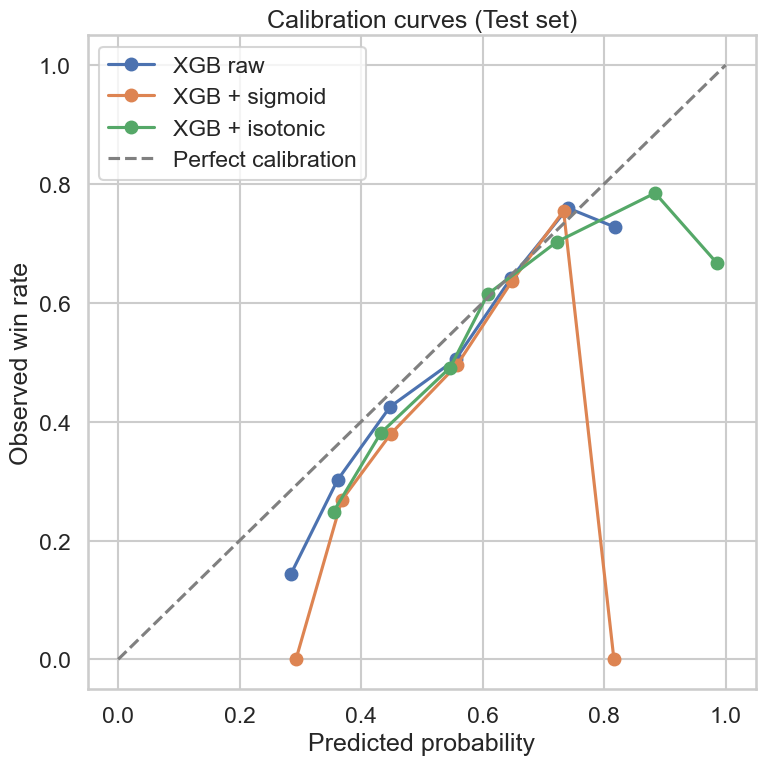

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

def plot_calibration(y_true, prob_dict, n_bins=10):
    plt.figure(figsize=(8, 8))

    for name, probs in prob_dict.items():
        frac_pos, mean_pred = calibration_curve(
            y_true, probs, n_bins=n_bins, strategy="uniform"
        )
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    # Línea perfecta
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")

    plt.xlabel("Predicted probability")
    plt.ylabel("Observed win rate")
    plt.title("Calibration curves (Test set)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_calibration(
    y_test,
    {
        "XGB raw": test_proba_raw,
        "XGB + sigmoid": test_proba_sigmoid,
        "XGB + isotonic": test_proba_isotonic
    }
)


#### 2.6.6.2 Feature Importance

In [119]:
importance = booster.get_score(importance_type="gain")

imp_df = (
    pd.DataFrame(
        {"feature": importance.keys(), "gain": importance.values()}
    )
    .sort_values("gain", ascending=False)
)

imp_df.head(15)

,feature,gain
15,H_WINRATE_last5,114.115196
49,DIFF_WINRATE_last5,56.366482
42,DIFF_PLUS_MINUS_roll5,43.971790
9,H_PLUS_MINUS_roll5,24.636833
32,A_WINRATE_last5,23.948051
33,DIFF_PTS_roll5,17.354572
16,A_PTS_roll5,13.941937
25,A_PLUS_MINUS_roll5,13.036557
38,DIFF_TOV_roll5,11.357959
30,A_DAYS_REST,10.503570


C:\Users\luis_\AppData\Local\Temp\ipykernel_25560\2715725441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


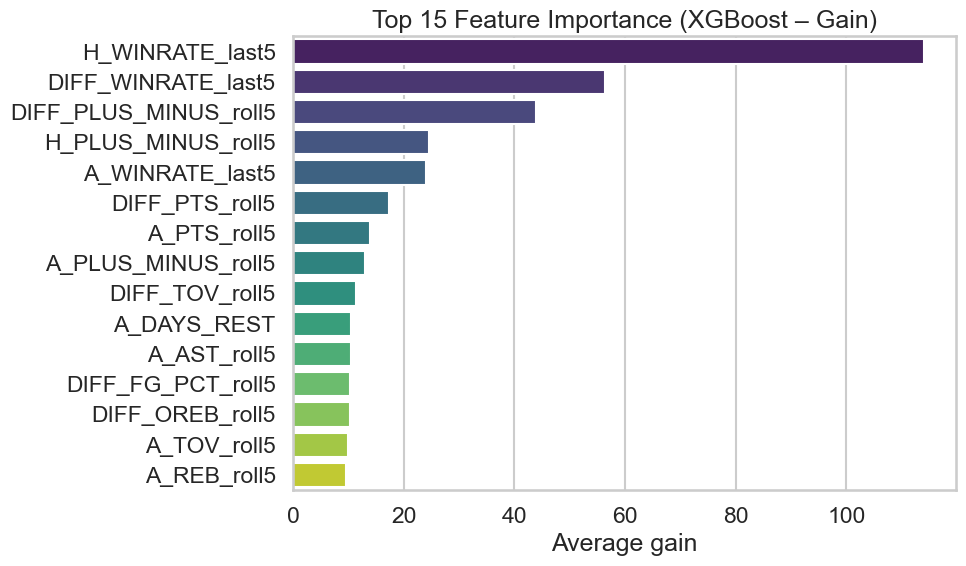

In [120]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=imp_df.head(15),
    x="gain",
    y="feature",
    palette="viridis"
)

plt.title("Top 15 Feature Importance (XGBoost – Gain)")
plt.xlabel("Average gain")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### 2.6.6.3 Otras Gráficas


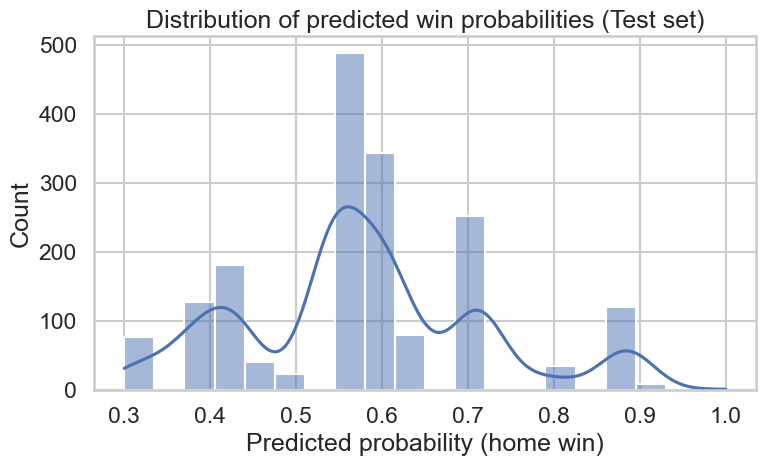

In [123]:
plt.figure(figsize=(8, 5))
sns.histplot(test_proba_isotonic, bins=20, kde=True)

plt.title("Distribution of predicted win probabilities (Test set)")
plt.xlabel("Predicted probability (home win)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

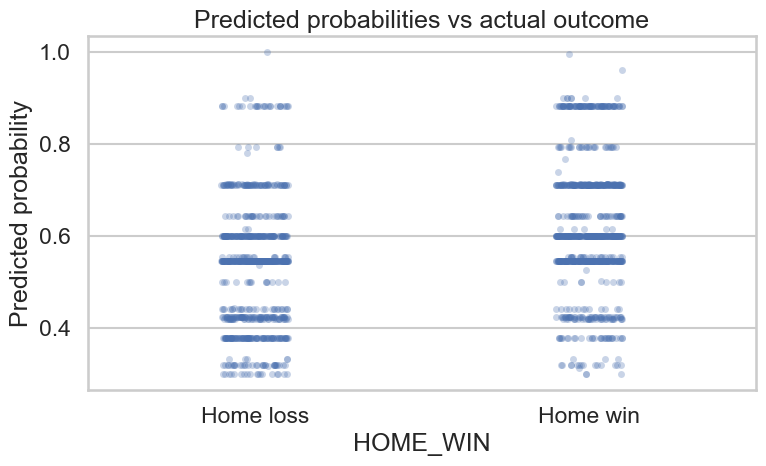

In [124]:
plt.figure(figsize=(8, 5))
sns.stripplot(
    x=y_test,
    y=test_proba_isotonic,
    alpha=0.3
)

plt.xticks([0, 1], ["Home loss", "Home win"])
plt.ylabel("Predicted probability")
plt.title("Predicted probabilities vs actual outcome")
plt.tight_layout()
plt.show()

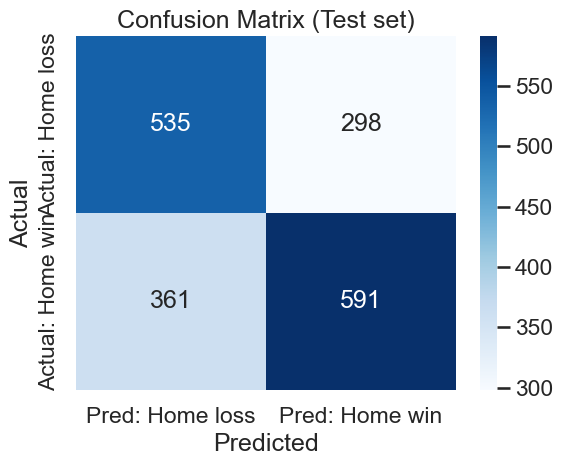

In [125]:
import numpy as np

# Usamos el modelo CALIBRADO (isotonic)
y_test_pred = (test_proba_isotonic >= 0.55).astype(int)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: Home loss", "Pred: Home win"],
    yticklabels=["Actual: Home loss", "Actual: Home win"]
)

plt.title("Confusion Matrix (Test set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()



### 2.6.7 Función de predicción de partidos (Demo)

In [121]:
import pandas as pd
import numpy as np

def build_single_game_features(
    df_team_feat: pd.DataFrame,
    home_abbr: str,
    away_abbr: str,
    as_of_date=None,
    window=5
) -> pd.DataFrame:
    """
    Construye 1 fila (game-level) con features H_/A_/DIFF_ usando df_team_feat.
    as_of_date: fecha del juego a predecir (str o datetime). Si None, usa la última fecha disponible + 1 día (proxy).
    """
    df = df_team_feat.copy()
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])

    home_abbr = home_abbr.upper()
    away_abbr = away_abbr.upper()

    if as_of_date is None:
        # Usamos "mañana" respecto al último juego disponible de ambos equipos
        last_date = min(
            df[df["TEAM_ABBREVIATION"] == home_abbr]["GAME_DATE"].max(),
            df[df["TEAM_ABBREVIATION"] == away_abbr]["GAME_DATE"].max()
        )
        as_of_date = last_date + pd.Timedelta(days=1)
    else:
        as_of_date = pd.to_datetime(as_of_date)

    # Tomamos el último registro ANTES de as_of_date para cada equipo
    home_hist = df[(df["TEAM_ABBREVIATION"] == home_abbr) & (df["GAME_DATE"] < as_of_date)].sort_values("GAME_DATE")
    away_hist = df[(df["TEAM_ABBREVIATION"] == away_abbr) & (df["GAME_DATE"] < as_of_date)].sort_values("GAME_DATE")

    if home_hist.empty or away_hist.empty:
        raise ValueError("No hay historial suficiente para uno de los equipos antes de esa fecha.")

    home_row = home_hist.iloc[-1].copy()
    away_row = away_hist.iloc[-1].copy()

    # Exigir que ambos tengan features pregame completas
    if int(home_row.get("HAS_ROLL_FEATURES", 0)) != 1 or int(away_row.get("HAS_ROLL_FEATURES", 0)) != 1:
        raise ValueError("Uno de los equipos no tiene features pregame completas (HAS_ROLL_FEATURES=0). Prueba con otra fecha.")

    # columnas que llevamos a H_ / A_
    roll_cols = [c for c in df.columns if c.endswith(f"_roll{window}")]
    std_cols  = [c for c in df.columns if c.endswith(f"_std{window}")]
    extra_cols = ["DAYS_REST","WIN_STREAK",f"WINRATE_last{window}","HAS_ROLL_FEATURES"]

    cols_to_use = [c for c in (roll_cols + std_cols + extra_cols) if c in df.columns]

    out = {}

    for c in cols_to_use:
        out[f"H_{c}"] = home_row[c]
        out[f"A_{c}"] = away_row[c]

    # Diferenciales (H - A)
    for c in roll_cols + std_cols:
        h, a = f"H_{c}", f"A_{c}"
        if h in out and a in out:
            out[f"DIFF_{c}"] = out[h] - out[a]

    if "H_DAYS_REST" in out and "A_DAYS_REST" in out:
        out["DIFF_DAYS_REST"] = out["H_DAYS_REST"] - out["A_DAYS_REST"]
    if "H_WIN_STREAK" in out and "A_WIN_STREAK" in out:
        out["DIFF_WIN_STREAK"] = out["H_WIN_STREAK"] - out["A_WIN_STREAK"]
    if f"H_WINRATE_last{window}" in out and f"A_WINRATE_last{window}" in out:
        out[f"DIFF_WINRATE_last{window}"] = out[f"H_WINRATE_last{window}"] - out[f"A_WINRATE_last{window}"]

    # Metadatos útiles (no features)
    out["AS_OF_DATE"] = as_of_date
    out["HOME_ABBR"] = home_abbr
    out["AWAY_ABBR"] = away_abbr

    return pd.DataFrame([out])


def predict_matchup_proba(
    df_team_feat: pd.DataFrame,
    feature_cols: list,
    home_abbr: str,
    away_abbr: str,
    as_of_date=None,
    calibrator=None,
    base_model=None,
    window: int = 5
):
    """
    Devuelve P(home win) y P(away win). Usa calibrator si lo pasas; si no, usa base_model.
    """
    row = build_single_game_features(df_team_feat, home_abbr, away_abbr, as_of_date=as_of_date, window=window)

    # Alinear a las columnas del entrenamiento
    X_one = row.reindex(columns=feature_cols).copy()

    if X_one.isna().any().any():
        missing = X_one.columns[X_one.isna().any()].tolist()
        raise ValueError(f"Faltan columnas/valores para inferencia: {missing[:10]}... (revisa consistencia de feature_cols).")

    if calibrator is not None:
        p_home = float(calibrator.predict_proba(X_one)[:, 1][0])
    elif base_model is not None:
        p_home = float(base_model.predict_proba(X_one)[:, 1][0])
    else:
        raise ValueError("Pasa calibrator (isotonic) o base_model (xgb_for_cal).")

    mensaje = f"P({home_abbr} wins) = {(p_home*100):.4f}% \nP({away_abbr} wins) = {((1-p_home)*100):.4f}% \nTomando los últimos {window} juegos de cada equipo antes de {row['AS_OF_DATE'].iloc[0]}"
    return mensaje 

    """return {
        "home": home_abbr,
        "away": away_abbr,
        "as_of_date": row["AS_OF_DATE"].iloc[0],
        "p_home_win": p_home,
        "p_away_win": 1.0 - p_home
    }"""


In [122]:
result = predict_matchup_proba(
    df_team_feat=df_team_feat,
    feature_cols=feature_cols,
    home_abbr="LAL",
    away_abbr="TOR",
    as_of_date="2025-12-12",
    calibrator=calibrator_isotonic,    
)
print(result)

P(LAL wins) = 64.2857% 
P(TOR wins) = 35.7143% 
Tomando los últimos 5 juegos de cada equipo antes de 2025-12-12 00:00:00
